# 🌋 XGBoost Model: Concept, Logic, and Theory

---

## 📘 Overview

**XGBoost (Extreme Gradient Boosting)** is an advanced implementation of gradient boosting decision trees.  
It builds an **ensemble of weak learners (decision trees)** sequentially, where each new tree tries to **correct the errors** made by the previous ones.

In earthquake applications — such as **classifying background vs triggered events** or **predicting aftershock occurrence** — XGBoost helps capture **non-linear, multi-dimensional relationships** between seismological parameters (e.g., magnitude, depth, spatial proximity, temporal decay).

---

## ⚙️ Core Logic

The key idea behind XGBoost is to **minimize a regularized objective function**:

$$
\mathcal{L}(\phi) = \sum_{i=1}^{n} l(y_i, \hat{y}_i) + \sum_{k=1}^{K} \Omega(f_k)
$$

Where:  
- \( l(y_i, \hat{y}_i) \): loss function (measures prediction error)  
- \( \Omega(f_k) \): regularization term (controls model complexity)  
- \( f_k \): individual decision tree  
- \( K \): total number of trees  
- \( \hat{y}_i \): predicted probability or class for event \( i \)

The **goal** is to minimize \( \mathcal{L}(\phi) \) by adding new trees that predict the **residual errors** from the previous iteration.

---

## 🌲 Additive Tree Model

XGBoost builds the model **additively**:

$$
\hat{y}_i^{(t)} = \hat{y}_i^{(t-1)} + f_t(x_i)
$$

At each iteration \( t \), a new function \( f_t \) (a regression tree) is added to minimize the overall objective.

---

## 🔍 Second-Order Taylor Approximation

The loss function is expanded using a **second-order Taylor series**:

$$
\mathcal{L}^{(t)} \approx \sum_{i=1}^{n} [ l(y_i, \hat{y}_i^{(t-1)}) + g_i f_t(x_i) + \frac{1}{2} h_i f_t(x_i)^2 ] + \Omega(f_t)
$$

Where:  
- \( g_i = \frac{\partial l(y_i, \hat{y}_i^{(t-1)})}{\partial \hat{y}_i^{(t-1)}} \): first derivative (gradient)  
- \( h_i = \frac{\partial^2 l(y_i, \hat{y}_i^{(t-1)})}{\partial (\hat{y}_i^{(t-1)})^2} \): second derivative (Hessian)

The model uses both first and second derivatives for optimization, making training faster and more robust.

---

## 📈 Regularization Term

Each tree \( f_t \) is regularized to penalize complexity:

$$
\Omega(f_t) = \gamma T + \frac{1}{2} \lambda \sum_{j=1}^{T} w_j^2
$$

Where:  
- \( T \): number of leaves (terminal nodes)  
- \( w_j \): weight (score) assigned to leaf \( j \)  
- \( \gamma \): penalty for adding a new leaf  
- \( \lambda \): L2 regularization term on leaf weights  

This ensures **simplicity** and avoids overfitting, especially important in small or noisy earthquake catalogs.

---

## 🧩 Optimal Leaf Weight

For each leaf \( j \), the optimal weight minimizing loss is:

$$
w_j^* = - \frac{\sum_{i \in I_j} g_i}{\sum_{i \in I_j} h_i + \lambda}
$$

where \( I_j \) represents the set of samples assigned to leaf \( j \).

The corresponding **reduction in loss** (gain) from making a split is:

$$
\text{Gain} = \frac{1}{2} \left[ \frac{(\sum_{i \in I_L} g_i)^2}{\sum_{i \in I_L} h_i + \lambda} + \frac{(\sum_{i \in I_R} g_i)^2}{\sum_{i \in I_R} h_i + \lambda} - \frac{(\sum_{i \in I} g_i)^2}{\sum_{i \in I} h_i + \lambda} \right] - \gamma
$$

This **gain** determines whether a feature split should occur — a split is made only if the gain exceeds \( \gamma \).

---

## 🧮 Training Objective (Binary Classification)

For binary classification (e.g., background vs triggered), the model minimizes **logistic loss**:

$$
l(y_i, \hat{y}_i) = - [y_i \log(\hat{p}_i) + (1 - y_i) \log(1 - \hat{p}_i)]
$$

and the predicted probability is given by the **sigmoid function**:

$$
\hat{p}_i = \frac{1}{1 + e^{-\hat{y}_i}}
$$

---

## 🧠 Why XGBoost for Seismic Data?

| Advantage | Relevance to Seismic Classification |
|------------|-------------------------------------|
| Handles nonlinear features | Earthquake patterns are highly nonlinear (spatial–temporal–magnitude). |
| Built-in regularization | Prevents overfitting on small or biased catalogs. |
| Feature importance ranking | Helps identify dominant predictors (e.g., inter-event time, distance, magnitude difference). |
| Parallelized computation | Efficient for large catalogs or dense GNSS networks. |
| Probabilistic outputs | Useful for threshold-based aftershock probability analysis. |

---

## ⚡ Typical Hyperparameters

| Parameter | Description | Example |
|------------|-------------|----------|
| `n_estimators` | Number of trees | 300 |
| `learning_rate` | Shrinks contribution of each tree | 0.05 |
| `max_depth` | Maximum tree depth | 6 |
| `subsample` | Fraction of samples used per tree | 0.8 |
| `colsample_bytree` | Fraction of features per tree | 0.8 |
| `lambda` | L2 regularization | 1 |
| `gamma` | Minimum loss reduction for split | 0.1 |
| `eval_metric` | Evaluation metric | `"logloss"` or `"auc"` |

---

## 🎯 Final Prediction

After \( K \) trees are trained, the model’s final prediction is:

$$
\hat{y}_i = \sum_{k=1}^{K} f_k(x_i)
$$

and the **predicted class** is:

$$
\hat{Y}_i =
\begin{cases}
1 & \text{if } \hat{p}_i \geq 0.5 \\
0 & \text{otherwise}
\end{cases}
$$

---

## 📊 In Earthquake Application

- **Input features**: magnitude, inter-event distance, inter-event time, fractal dimension, etc.  
- **Target variable**: background (0) vs triggered (1) events.  
- **Output**: event probability of being triggered.

This helps in **declustering catalogs**, improving **seismic hazard models**, and interpreting **spatio-temporal clustering behavior** in seismicity.

---



In [3]:
"""
ExtremeGradient Boosting Model Training and Prediction
This notebook trains a Random Forest model on earthquake catalog data,
evaluates performance, and applies it to new datasets.
"""

import os
import warnings
from datetime import datetime


import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.metrics import (accuracy_score, classification_report, confusion_matrix,
f1_score, precision_score, recall_score, roc_auc_score, roc_curve)
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.preprocessing import LabelEncoder
from xgboost import XGBClassifier, plot_importance
from sklearn.preprocessing import StandardScaler


warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['figure.figsize'] = (12, 8)



In [4]:

# ============================================================================
# STEP 1: LOAD AND EXPLORE DATA
# ============================================================================
print("\n[STEP 1] Loading earthquake catalog data...")

# Load the training data
train_file = "/home/ashraf/Desktop/THESIS-FINAL/TRAIN-DATA/mld_final-nz_synthetic_catalog.csv"  
df = pd.read_csv(train_file)

print(f"✓ Data loaded successfully!")
print(f"  Shape: {df.shape}")
print(f"\nFirst few rows:")
df.head()



[STEP 1] Loading earthquake catalog data...
✓ Data loaded successfully!
  Shape: (100503, 20)

First few rows:


,event,DateTime,Date,Year,Month,Day,time,latitude,longitude,magnitude,Generation,ParentID,Label,i+,N+,T+,R+,dm+,n_child,n_parent
0,8,2005-01-01 01:10:00.825848852,2005-01-01,2005,1,1,0.048621,-37.396225,177.987203,3.301688,0,NaN,background,0,2.097547e-04,0.000694,3.021055e-01,0.176485,0.036315,0.036315
1,41,2005-01-01 05:42:37.953139645,2005-01-01,2005,1,1,0.237939,-37.124231,177.535453,3.163747,1,1754.0,triggered,1,2.702490e-05,0.003774,7.160450e-03,0.137941,0.036315,0.036315
2,46,2005-01-01 05:43:05.509842873,2005-01-01,2005,1,1,0.238258,-37.123676,177.537697,3.500583,1,1754.0,triggered,2,1.064500e-11,0.000007,1.421550e-06,-0.336836,0.072630,0.036315
3,47,2005-01-01 05:43:17.946950013,2005-01-01,2005,1,1,0.238402,-42.631090,167.284364,3.736844,0,NaN,background,3,1.811590e-06,0.000002,7.991986e-01,-0.236261,0.000000,0.072630
4,48,2005-01-01 05:43:23.387341987,2005-01-01,2005,1,1,0.238465,-37.123590,177.536278,3.048787,1,1754.0,triggered,3,1.428314e-12,0.000003,4.383602e-07,0.451797,0.036315,0.072630


In [5]:

print(f"\nColumn names:")
print(df.columns.tolist())

print(f"\nData types:")
print(df.dtypes)

print(f"\nMissing values:")
print(df.isnull().sum())

print(f"\nBasic statistics:")
df.describe()


Column names:
['event', 'DateTime', 'Date', 'Year', 'Month', 'Day', 'time', 'latitude', 'longitude', 'magnitude', 'Generation', 'ParentID', 'Label', 'i+', 'N+', 'T+', 'R+', 'dm+', 'n_child', 'n_parent']

Data types:
event           int64
DateTime       object
Date           object
Year            int64
Month           int64
Day             int64
time          float64
latitude      float64
longitude     float64
magnitude     float64
Generation      int64
ParentID      float64
Label          object
i+              int64
N+            float64
T+            float64
R+            float64
dm+           float64
n_child       float64
n_parent      float64
dtype: object

Missing values:
event             0
DateTime          0
Date              0
Year              0
Month             0
Day               0
time              0
latitude          0
longitude         0
magnitude         0
Generation        0
ParentID      29671
Label             0
i+                0
N+                0
T+          

,event,Year,Month,Day,time,latitude,longitude,magnitude,Generation,ParentID,i+,N+,T+,R+,dm+,n_child,n_parent
count,1.005030e+05,100503.000000,100503.000000,100503.000000,100503.000000,100503.000000,100503.000000,100503.000000,100503.000000,70832.000000,100503.000000,1.005030e+05,1.005030e+05,1.005030e+05,100503.000000,100503.000000,100503.000000
mean,4.998227e+05,2009.473339,6.516014,15.753749,1815.951577,-40.491403,172.512215,3.433102,0.704775,8521.268142,48360.183756,6.997577e-06,4.996070e-02,9.138820e-03,1.092697,0.036315,10.996242
std,2.886813e+05,2.873401,3.433659,8.859918,1054.854397,3.759394,3.736498,0.433243,0.456146,4924.521953,29446.504210,1.587850e-05,5.344314e-01,5.344746e-02,1.490378,0.630884,40.608410
min,8.000000e+00,2005.000000,1.000000,1.000000,0.048621,-46.999943,166.000059,3.000005,0.000000,4.000000,0.000000,1.274211e-18,2.454859e-11,6.808480e-12,-3.696612,0.000000,0.036315
25%,2.506415e+05,2007.000000,4.000000,8.000000,901.201875,-43.809479,169.285313,3.125275,0.000000,4212.250000,20799.000000,2.606959e-12,1.564265e-05,1.058604e-07,0.042632,0.000000,0.072630
50%,5.005710e+05,2009.000000,7.000000,16.000000,1804.980886,-40.487934,172.497110,3.299426,1.000000,8540.000000,47630.000000,3.699105e-11,1.002774e-04,7.750077e-07,0.655338,0.000000,0.108945
75%,7.495705e+05,2012.000000,9.000000,23.000000,2732.180995,-37.203004,175.732346,3.599903,1.000000,12789.000000,74049.500000,6.556254e-06,2.537463e-03,6.221768e-04,1.877019,0.036315,0.472096
max,1.000027e+06,2014.000000,12.000000,31.000000,3649.777664,-34.000236,178.999147,8.128535,1.000000,17013.000000,100501.000000,2.960072e-04,4.988597e+01,2.086598e+00,5.128346,184.734973,184.734973


In [6]:

# ============================================================================
# STEP 2: DATA PREPROCESSING
# ============================================================================
print("\n" + "=" * 80)
print("[STEP 2] Data Preprocessing...")
print("=" * 80)

# Identify the label column (target variable)
# Common names: 'label', 'Label', 'class', 'Class', 'target', 'category'
label_columns = ['label', 'Label', 'class', 'Class', 'target', 'category', 'type', 'Type']
label_col = None

for col in label_columns:
    if col in df.columns:
        label_col = col
        break

if label_col is None:
    print("\n⚠ Could not automatically detect label column.")
    print(f"Available columns: {df.columns.tolist()}")
    label_col = input("Please enter the name of your label/target column: ")

print(f"\n✓ Using '{label_col}' as target variable")

# Check label distribution
print(f"\nLabel distribution:")
print(df[label_col].value_counts())



[STEP 2] Data Preprocessing...

✓ Using 'Label' as target variable

Label distribution:
Label
triggered     70832
background    29671
Name: count, dtype: int64


# Correlation Matrix

Label Distribution:
Label       Label_encoded
triggered   1                70832
background  0                29671
Name: count, dtype: int64



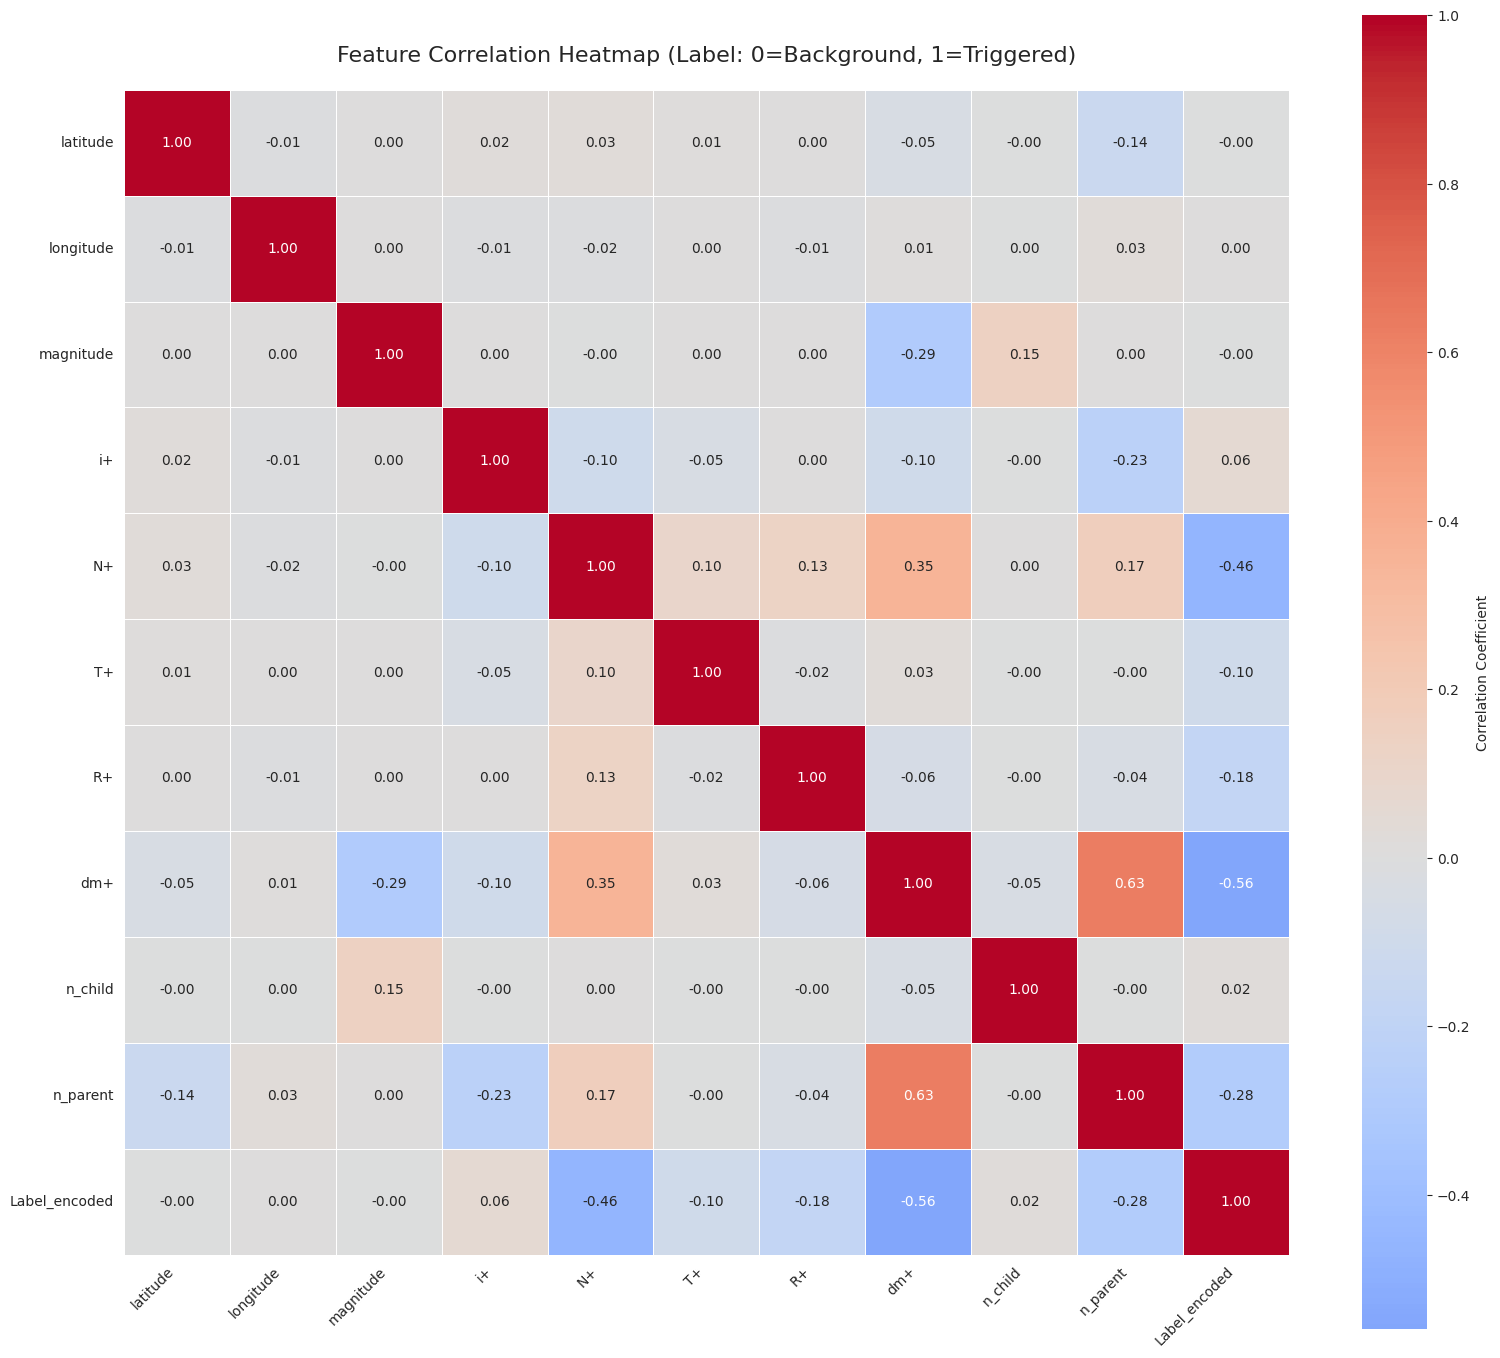

In [7]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np


df_encoded = df.copy()

# Encode Label: background=0, triggered=1 (or aftershock=1)
df_encoded['Label_encoded'] = df_encoded['Label'].map({'background': 0, 'triggered': 1})

# Check the encoding
print("Label Distribution:")
print(df_encoded[['Label', 'Label_encoded']].value_counts())
print()

# Select numeric columns including the encoded label
numeric_cols = ['latitude', 'longitude', 
                'magnitude', 'i+', 'N+', 'T+', 
                'R+', 'dm+', 'n_child', 'n_parent', 'Label_encoded']

# Calculate correlation matrix
correlation_matrix = df_encoded[numeric_cols].corr()

# Create heatmap
plt.figure(figsize=(16, 14))
sns.heatmap(correlation_matrix, 
            annot=True,
            cmap='coolwarm',
            center=0,
            fmt='.2f',
            square=True,
            linewidths=0.5,
            cbar_kws={'label': 'Correlation Coefficient'})
plt.title('Feature Correlation Heatmap (Label: 0=Background, 1=Triggered)', fontsize=16, pad=20)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

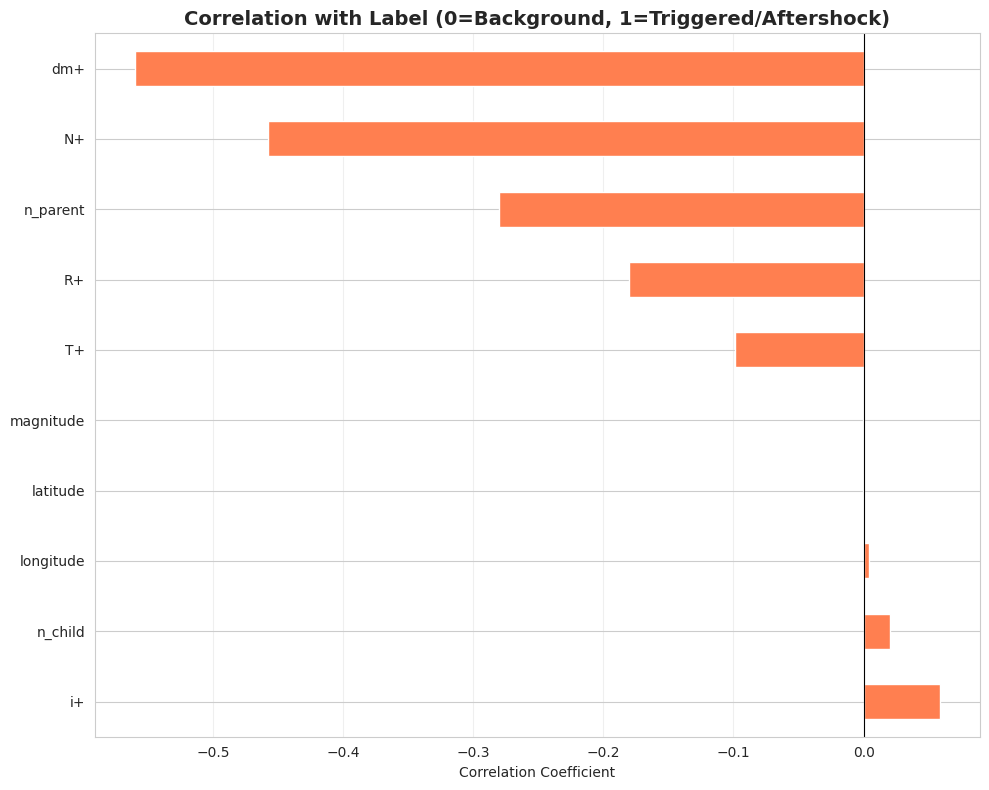

Correlations with Label (Background vs Triggered):
Label_encoded    1.000000
i+               0.058488
n_child          0.020560
longitude        0.004078
latitude        -0.000296
magnitude       -0.000383
T+              -0.099004
R+              -0.179938
n_parent        -0.279924
N+              -0.457913
dm+             -0.559624
Name: Label_encoded, dtype: float64



In [8]:
# Correlation with Label_encoded
label_corr = correlation_matrix['Label_encoded'].sort_values(ascending=False)

plt.figure(figsize=(10, 8))
label_corr[label_corr.index != 'Label_encoded'].plot(kind='barh', color='coral')
plt.title('Correlation with Label (0=Background, 1=Triggered/Aftershock)', fontsize=14, fontweight='bold')
plt.xlabel('Correlation Coefficient')
plt.axvline(x=0, color='black', linestyle='-', linewidth=0.8)
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

print("Correlations with Label (Background vs Triggered):")
print(label_corr)
print()

In [9]:
# Compare features between background and triggered events
print("Feature Statistics by Label:")
print("="*70)

for col in ['magnitude', 'Generation', 'N+', 'T+', 'R+', 'dm+', 'n_child', 'n_parent']:
    print(f"\n{col}:")
    print(df_encoded.groupby('Label')[col].describe()[['mean', 'std', 'min', 'max']])

Feature Statistics by Label:

magnitude:
                mean       std       min       max
Label                                             
background  3.433359  0.433562  3.000011  7.868713
triggered   3.432995  0.433113  3.000005  8.128535

Generation:
            mean  std  min  max
Label                          
background   0.0  0.0  0.0  0.0
triggered    1.0  0.0  1.0  1.0

N+:
                mean       std           min       max
Label                                                 
background  0.000018  0.000021  3.079327e-10  0.000259
triggered   0.000002  0.000010  1.274211e-18  0.000296

T+:
                mean       std           min        max
Label                                                  
background  0.131712  0.900498  9.181192e-10  49.885966
triggered   0.015716  0.248228  2.454859e-11  30.801005

R+:
                mean       std           min       max
Label                                                 
background  0.023998  0.085639  1.180149e-08 

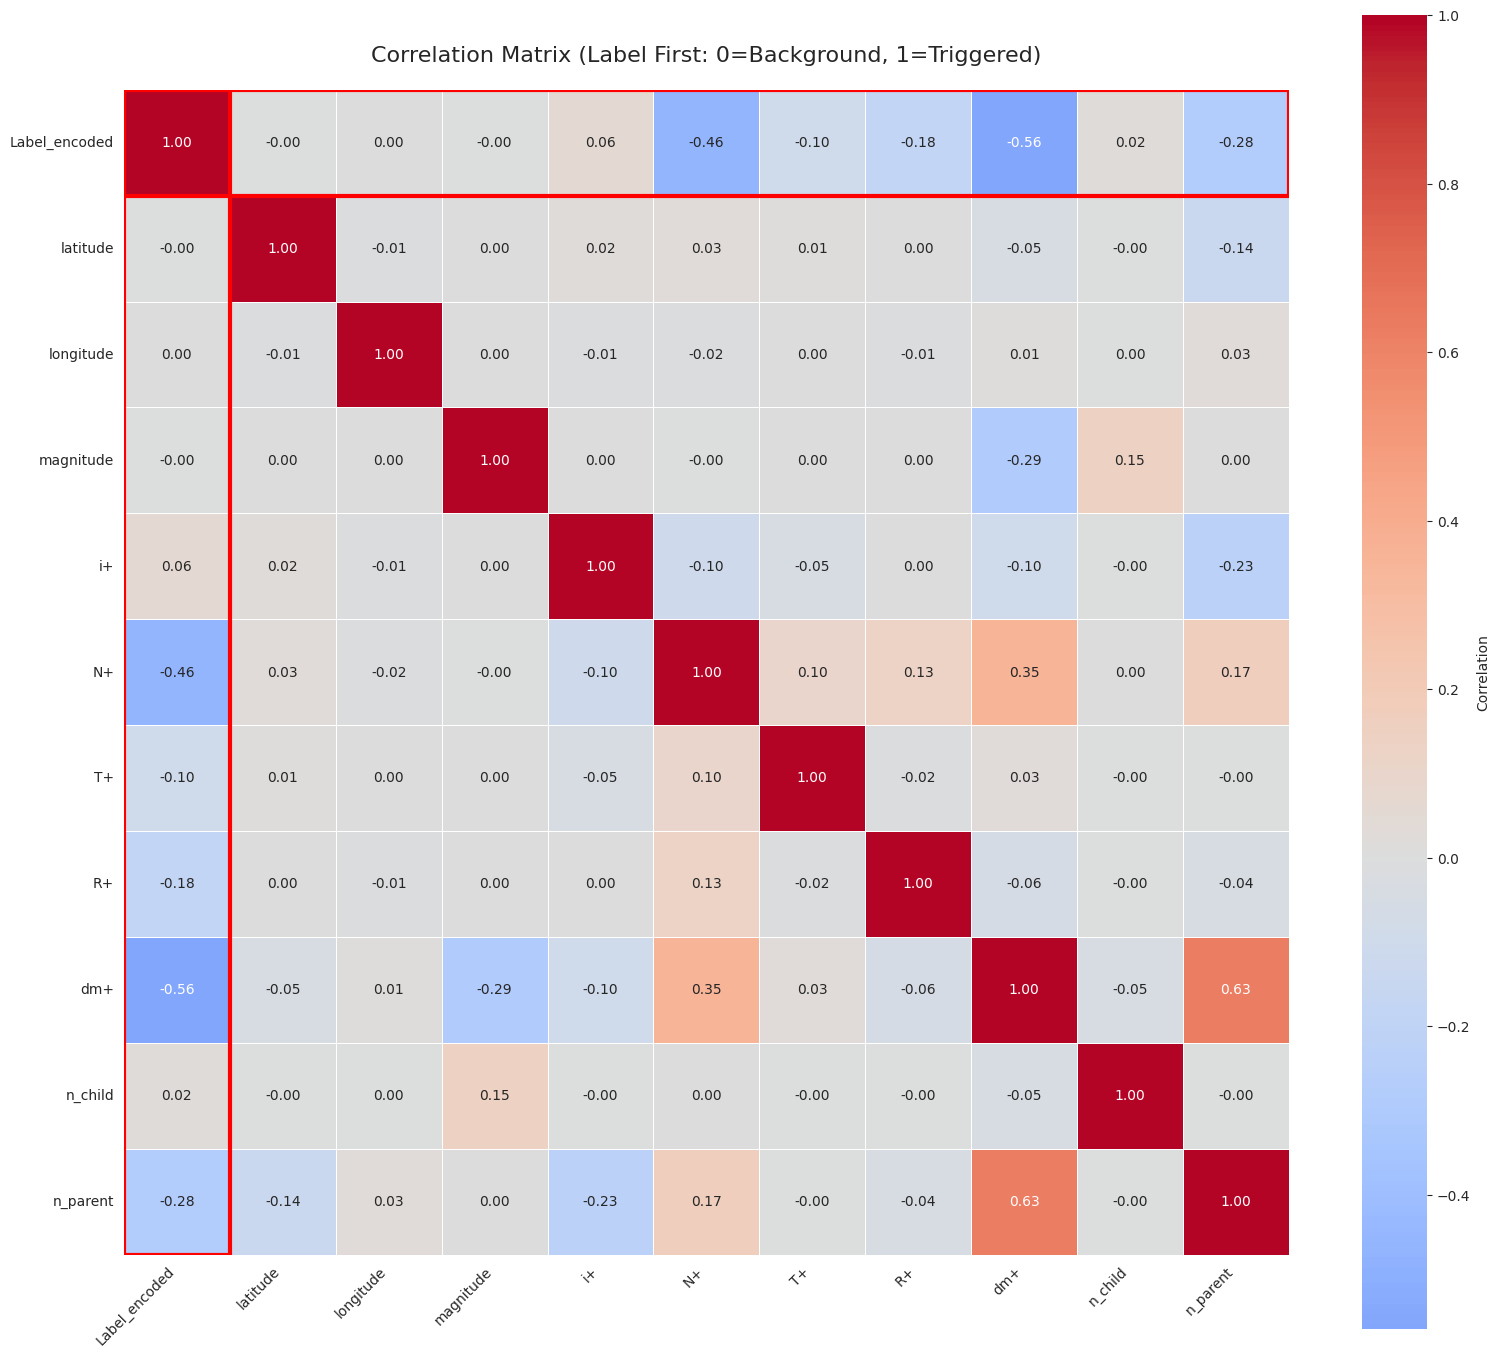

In [10]:
# Reorder columns to put Label_encoded first or last for emphasis
cols_reordered = ['Label_encoded'] + [col for col in numeric_cols if col != 'Label_encoded']
corr_reordered = df_encoded[cols_reordered].corr()

plt.figure(figsize=(16, 14))
sns.heatmap(corr_reordered, 
            annot=True,
            cmap='coolwarm',
            center=0,
            fmt='.2f',
            square=True,
            linewidths=0.5,
            cbar_kws={'label': 'Correlation'})
plt.title('Correlation Matrix (Label First: 0=Background, 1=Triggered)', fontsize=16, pad=20)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)

# Highlight Label row/column
ax = plt.gca()
ax.add_patch(plt.Rectangle((0, 0), len(cols_reordered), 1, fill=False, edgecolor='red', lw=3))
ax.add_patch(plt.Rectangle((0, 0), 1, len(cols_reordered), fill=False, edgecolor='red', lw=3))

plt.tight_layout()
plt.show()

In [11]:

# Separate features and target
X = df.drop(columns=[label_col])
y = df[label_col]

# Identify feature columns that match N+, R+, etc. pattern
feature_cols =  ['N+', 'R+', 'T+',  'dm+', 'n_child', 'n_parent']

if not feature_cols:
    # If no specific pattern found, use all numeric columns
    feature_cols = X.select_dtypes(include=[np.number]).columns.tolist()

print(f"\n✓ Selected features ({len(feature_cols)}):")
for i, col in enumerate(feature_cols, 1):
    print(f"  {i}. {col}")

# Select only the feature columns
X = X[feature_cols]

# Handle missing values
if X.isnull().sum().sum() > 0:
    print(f"\n⚠ Handling {X.isnull().sum().sum()} missing values...")
    X = X.fillna(X.median())
    print("✓ Missing values filled with median")

# Encode target variable if it's categorical
le = None
if y.dtype == 'object' or y.dtype.name == 'category':
    print(f"\n✓ Encoding target variable...")
    le = LabelEncoder()
    y_encoded = le.fit_transform(y)
    print(f"  Classes: {le.classes_}")
    y = pd.Series(y_encoded, index=y.index)
else:
    y_encoded = y


✓ Selected features (6):
  1. N+
  2. R+
  3. T+
  4. dm+
  5. n_child
  6. n_parent

✓ Encoding target variable...
  Classes: ['background' 'triggered']


In [12]:

# ============================================================================
# STEP 3: SPLIT DATA
# ============================================================================
print("\n" + "=" * 80)
print("[STEP 3] Splitting data into train and test sets...")
print("=" * 80)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"✓ Data split completed!")
print(f"  Training set: {X_train.shape[0]} samples")
print(f"  Test set: {X_test.shape[0]} samples")
print(f"  Features: {X_train.shape[1]}")



[STEP 3] Splitting data into train and test sets...
✓ Data split completed!
  Training set: 80402 samples
  Test set: 20101 samples
  Features: 6


#  Initialize and train XGBClassifier

In [13]:
# ============================================================================
# STEP 4: Initialize and train XGBClassifier
# ============================================================================
print("\n" + "=" * 80)
print("[STEP 4] Training Xtreme Gradient Boosting Classifier...")
print("=" * 80)


# Optional: scale features for stability
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Initialize the Gradient Boosting model

xgb_model = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    use_label_encoder=False,
    eval_metric='logloss',
    random_state=42
    )

print("Fitting XGBoost model...")
# Fit the model
xgb_model.fit(X_train_scaled, y_train)

print("✓ Model training complete!")
# ============================================================================


[STEP 4] Training Xtreme Gradient Boosting Classifier...
Fitting XGBoost model...
✓ Model training complete!


# Hyper parameter tuning

In [14]:
# ============================================================================
# STEP 4: Hyperparameter Tuning for XGBoost
# ============================================================================
from sklearn.model_selection import RandomizedSearchCV
from xgboost import XGBClassifier
from sklearn.preprocessing import StandardScaler
from scipy.stats import uniform, randint
import numpy as np

print("\n" + "=" * 80)
print("[STEP 4] Hyperparameter Tuning: Xtreme Gradient Boosting Classifier...")
print("=" * 80)

# Optional: scale features for stability
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Base model
xgb_base = XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)

# Parameter grid for tuning
param_dist = {
    'n_estimators': randint(100, 600),
    'max_depth': randint(3, 10),
    'learning_rate': uniform(0.01, 0.3),
    'subsample': uniform(0.6, 0.4),
    'colsample_bytree': uniform(0.6, 0.4),
    'gamma': uniform(0, 0.5),
    'min_child_weight': randint(1, 10)
}

# Randomized Search
random_search = RandomizedSearchCV(
    estimator=xgb_base,
    param_distributions=param_dist,
    n_iter=40,              # Number of parameter settings sampled
    scoring='accuracy',     # You can use f1, roc_auc, etc.
    cv=5,
    verbose=2,
    random_state=42,
    n_jobs=-1
)

print("🔍 Starting randomized search for best hyperparameters...")
random_search.fit(X_train_scaled, y_train)

print("\nBest parameters found:")
print(random_search.best_params_)
print(f"Best cross-validation accuracy: {random_search.best_score_:.4f}")

# Use the best model
xgb_best = random_search.best_estimator_
xgb_best.fit(X_train_scaled, y_train)

print("✓ Model training complete with optimized hyperparameters!")
# ============================================================================

# Evaluate
y_pred = xgb_best.predict(X_test_scaled)
print("Test Accuracy:", (y_pred == y_test).mean())



[STEP 4] Hyperparameter Tuning: Xtreme Gradient Boosting Classifier...
🔍 Starting randomized search for best hyperparameters...
Fitting 5 folds for each of 40 candidates, totalling 200 fits


/home/ashraf/.local/lib/python3.10/site-packages/xgboost/training.py:183: UserWarning: [15:15:10] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/ashraf/.local/lib/python3.10/site-packages/xgboost/training.py:183: UserWarning: [15:15:10] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/ashraf/.local/lib/python3.10/site-packages/xgboost/training.py:183: UserWarning: [15:15:10] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/ashraf/.local/lib/python3.10/site-packages/xgboost/training.py:183: UserWarning: [15:15:10] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/ashraf/.local/lib/python3.10/site-packages/xgboost/trainin

[CV] END colsample_bytree=0.749816047538945, gamma=0.4753571532049581, learning_rate=0.22959818254342154, max_depth=7, min_child_weight=5, n_estimators=202, subsample=0.7783331011414365; total time=   2.0s
[CV] END colsample_bytree=0.749816047538945, gamma=0.4753571532049581, learning_rate=0.22959818254342154, max_depth=7, min_child_weight=5, n_estimators=202, subsample=0.7783331011414365; total time=   2.0s
[CV] END colsample_bytree=0.749816047538945, gamma=0.4753571532049581, learning_rate=0.22959818254342154, max_depth=7, min_child_weight=5, n_estimators=202, subsample=0.7783331011414365; total time=   2.2s


/home/ashraf/.local/lib/python3.10/site-packages/xgboost/training.py:183: UserWarning: [15:15:13] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/ashraf/.local/lib/python3.10/site-packages/xgboost/training.py:183: UserWarning: [15:15:13] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/ashraf/.local/lib/python3.10/site-packages/xgboost/training.py:183: UserWarning: [15:15:13] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[CV] END colsample_bytree=0.749816047538945, gamma=0.4753571532049581, learning_rate=0.22959818254342154, max_depth=7, min_child_weight=5, n_estimators=202, subsample=0.7783331011414365; total time=   2.4s
[CV] END colsample_bytree=0.749816047538945, gamma=0.4753571532049581, learning_rate=0.22959818254342154, max_depth=7, min_child_weight=5, n_estimators=202, subsample=0.7783331011414365; total time=   2.4s


...

[CV] END colsample_bytree=0.7400313630778703, gamma=0.3225516810152824, learning_rate=0.2106772178989299, max_depth=3, min_child_weight=5, n_estimators=416, subsample=0.7996773519539009; total time=   2.3s
[CV] END colsample_bytree=0.6975958573516334, gamma=0.4865052773762228, learning_rate=0.1279293174000281, max_depth=8, min_child_weight=8, n_estimators=382, subsample=0.7737577462041715; total time=   3.9s


/home/ashraf/.local/lib/python3.10/site-packages/xgboost/training.py:183: UserWarning: [15:16:37] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/ashraf/.local/lib/python3.10/site-packages/xgboost/training.py:183: UserWarning: [15:16:37] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[CV] END colsample_bytree=0.6975958573516334, gamma=0.4865052773762228, learning_rate=0.1279293174000281, max_depth=8, min_child_weight=8, n_estimators=382, subsample=0.7737577462041715; total time=   4.3s
[CV] END colsample_bytree=0.6975958573516334, gamma=0.4865052773762228, learning_rate=0.1279293174000281, max_depth=8, min_child_weight=8, n_estimators=382, subsample=0.7737577462041715; total time=   4.1s
[CV] END colsample_bytree=0.6975958573516334, gamma=0.4865052773762228, learning_rate=0.1279293174000281, max_depth=8, min_child_weight=8, n_estimators=382, subsample=0.7737577462041715; total time=   4.6s
[CV] END colsample_bytree=0.8288016796836732, gamma=0.3842770071531545, learning_rate=0.023081131526330123, max_depth=6, min_child_weight=5, n_estimators=105, subsample=0.7480634801021777; total time=   0.8s


/home/ashraf/.local/lib/python3.10/site-packages/xgboost/training.py:183: UserWarning: [15:16:38] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/ashraf/.local/lib/python3.10/site-packages/xgboost/training.py:183: UserWarning: [15:16:38] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/ashraf/.local/lib/python3.10/site-packages/xgboost/training.py:183: UserWarning: [15:16:38] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[CV] END colsample_bytree=0.7400313630778703, gamma=0.3225516810152824, learning_rate=0.2106772178989299, max_depth=3, min_child_weight=5, n_estimators=416, subsample=0.7996773519539009; total time=   2.5s
[CV] END colsample_bytree=0.8288016796836732, gamma=0.3842770071531545, learning_rate=0.023081131526330123, max_depth=6, min_child_weight=5, n_estimators=105, subsample=0.7480634801021777; total time=   0.9s
[CV] END colsample_bytree=0.8288016796836732, gamma=0.3842770071531545, learning_rate=0.023081131526330123, max_depth=6, min_child_weight=5, n_estimators=105, subsample=0.7480634801021777; total time=   0.7s
[CV] END colsample_bytree=0.8288016796836732, gamma=0.3842770071531545, learning_rate=0.023081131526330123, max_depth=6, min_child_weight=5, n_estimators=105, subsample=0.7480634801021777; total time=   0.7s
[CV] END colsample_bytree=0.8288016796836732, gamma=0.3842770071531545, learning_rate=0.023081131526330123, max_depth=6, min_child_weight=5, n_estimators=105, subsample=0

In [15]:
best_params = random_search.best_params_

xgb_model = XGBClassifier(
    n_estimators=best_params['n_estimators'],
    learning_rate=best_params['learning_rate'],
    max_depth=best_params['max_depth'],
    subsample=best_params['subsample'],
    colsample_bytree=best_params['colsample_bytree'],
    gamma=best_params['gamma'],
    min_child_weight=best_params['min_child_weight'],
    random_state=42,
    eval_metric='logloss'
)

xgb_model.fit(X_train_scaled, y_train)
print("✓ Model retrained with optimized hyperparameters!")
print("\n" + "=" * 80)
# Predict on test data
y_pred = xgb_model.predict(X_test_scaled)

# Print evaluation metrics
print(f"\nAccuracy: {accuracy_score(y_test, y_pred):.4f}")
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))



✓ Model retrained with optimized hyperparameters!


Accuracy: 0.9744

Confusion Matrix:
 [[ 5599   335]
 [  179 13988]]

Classification Report:
               precision    recall  f1-score   support

           0       0.97      0.94      0.96      5934
           1       0.98      0.99      0.98     14167

    accuracy                           0.97     20101
   macro avg       0.97      0.97      0.97     20101
weighted avg       0.97      0.97      0.97     20101



# End tuning


[STEP 5] Evaluating Model Performance...

Accuracy: 0.9744

Confusion Matrix:
 [[ 5599   335]
 [  179 13988]]

Classification Report:
               precision    recall  f1-score   support

           0       0.97      0.94      0.96      5934
           1       0.98      0.99      0.98     14167

    accuracy                           0.97     20101
   macro avg       0.97      0.97      0.97     20101
weighted avg       0.97      0.97      0.97     20101



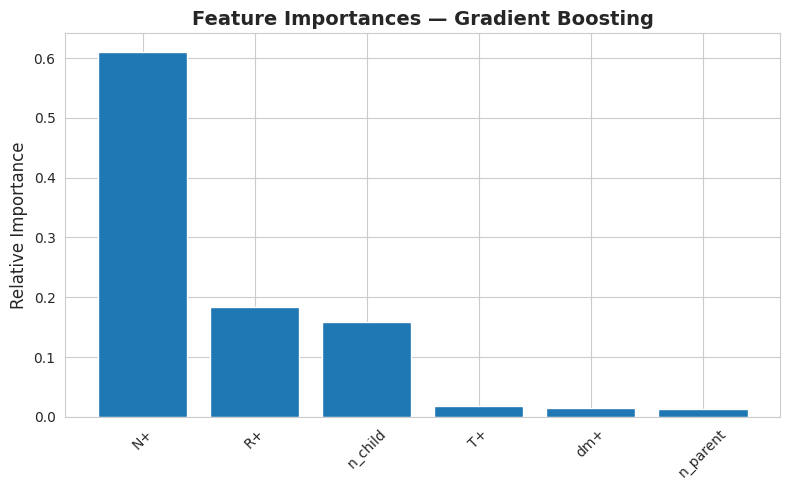

In [16]:
print("\n" + "=" * 80)
print("[STEP 5] Evaluating Model Performance...")
print("=" * 80)

# Predict on test data
y_pred = xgb_model.predict(X_test_scaled)

# Print evaluation metrics
print(f"\nAccuracy: {accuracy_score(y_test, y_pred):.4f}")
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))




importances = xgb_model.feature_importances_
indices = np.argsort(importances)[::-1]

plt.figure(figsize=(8,5))
plt.title("Feature Importances — Gradient Boosting", fontsize=14, weight='bold')
plt.bar(range(len(importances)), importances[indices], align="center")
plt.xticks(range(len(importances)), [feature_cols[i] for i in indices], rotation=45)
plt.ylabel("Relative Importance", fontsize=12)
plt.tight_layout()
plt.show()


# Accuracy Metrics

In [17]:
from sklearn.model_selection import cross_val_score

# -----------------------
# Accuracy Metrics
# -----------------------

train_acc = xgb_model.score(X_train_scaled, y_train)
test_acc = xgb_model.score(X_test_scaled, y_test)
cv_acc = cross_val_score(xgb_model, X_train_scaled, y_train, cv=5).mean()

print(f"Train Accuracy: {train_acc:.4f}")
print(f"Test Accuracy:  {test_acc:.4f}")
print(f"Cross-Val Accuracy (5-fold): {cv_acc:.4f}")


Train Accuracy: 0.9744
Test Accuracy:  0.9744
Cross-Val Accuracy (5-fold): 0.9712



[STEP 5] Model Evaluation...

MODEL PERFORMANCE METRICS
Training Accuracy:        0.9744
Test Accuracy:            0.9744
Precision:                0.9766
Recall:                   0.9874
F1 Score:                 0.9820
Cross-Val Accuracy:       0.9712 (+/- 0.0008)
Generalization Gap:       -0.0000

DETAILED CLASSIFICATION REPORT
              precision    recall  f1-score   support

  background       0.97      0.94      0.96      5934
   triggered       0.98      0.99      0.98     14167

    accuracy                           0.97     20101
   macro avg       0.97      0.97      0.97     20101
weighted avg       0.97      0.97      0.97     20101


Confusion Matrix:
[[ 5599   335]
 [  179 13988]]


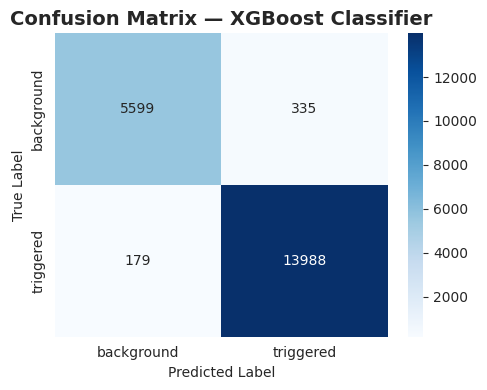

In [18]:
# ============================================================================
# STEP 5: MODEL EVALUATION
# ============================================================================
print("\n" + "=" * 80)
print("[STEP 5] Model Evaluation...")
print("=" * 80)

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report
)
from sklearn.model_selection import cross_val_score
import numpy as np

# ======================================================
# Predictions (using scaled data, as model was trained that way)
# ======================================================
y_train_pred = xgb_model.predict(X_train_scaled)
y_test_pred = xgb_model.predict(X_test_scaled)
y_test_proba = xgb_model.predict_proba(X_test_scaled)

# ======================================================
# Basic Accuracy Metrics
# ======================================================
train_accuracy = accuracy_score(y_train, y_train_pred)
test_accuracy = accuracy_score(y_test, y_test_pred)

# Determine if binary or multiclass classification
is_binary = len(np.unique(y)) == 2
average_method = 'binary' if is_binary else 'weighted'

precision = precision_score(y_test, y_test_pred, average=average_method, zero_division=0)
recall = recall_score(y_test, y_test_pred, average=average_method, zero_division=0)
f1 = f1_score(y_test, y_test_pred, average=average_method, zero_division=0)

# ======================================================
# Cross-validation Accuracy (on training set)
# ======================================================
cv_scores = cross_val_score(xgb_model, X_train_scaled, y_train, cv=5, scoring='accuracy')

# ======================================================
# Print metrics summary
# ======================================================
print("\n" + "=" * 50)
print("MODEL PERFORMANCE METRICS")
print("=" * 50)
print(f"Training Accuracy:        {train_accuracy:.4f}")
print(f"Test Accuracy:            {test_accuracy:.4f}")
print(f"Precision:                {precision:.4f}")
print(f"Recall:                   {recall:.4f}")
print(f"F1 Score:                 {f1:.4f}")
print(f"Cross-Val Accuracy:       {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})")

# Generalization gap (overfitting check)
print(f"Generalization Gap:       {train_accuracy - test_accuracy:.4f}")

# ======================================================
# Detailed Classification Report
# ======================================================
print("\n" + "=" * 50)
print("DETAILED CLASSIFICATION REPORT")
print("=" * 50)
if le is not None:
    target_names = le.classes_
else:
    target_names = [f"Class {i}" for i in np.unique(y)]

print(classification_report(y_test, y_test_pred, target_names=target_names))

# ======================================================
# Confusion Matrix
# ======================================================
cm = confusion_matrix(y_test, y_test_pred)
print("\nConfusion Matrix:")
print(cm)

# Optional: visualize confusion matrix
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=target_names, yticklabels=target_names)
plt.title("Confusion Matrix — XGBoost Classifier", fontsize=14, weight='bold')
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.show()


In [19]:
from sklearn.model_selection import cross_val_score

# Accuracy on training data
train_acc = xgb_model.score(X_train_scaled, y_train)

# Accuracy on test data
test_acc = xgb_model.score(X_test_scaled, y_test)

# Cross-validation accuracy
cv_acc = cross_val_score(xgb_model, X_train_scaled, y_train, cv=5, scoring='accuracy').mean()

print(f"Train Accuracy:      {train_acc:.4f}")
print(f"Test Accuracy:       {test_acc:.4f}")
print(f"Cross-Val Accuracy:  {cv_acc:.4f}")


Train Accuracy:      0.9744
Test Accuracy:       0.9744
Cross-Val Accuracy:  0.9712


# Confusion Matrix

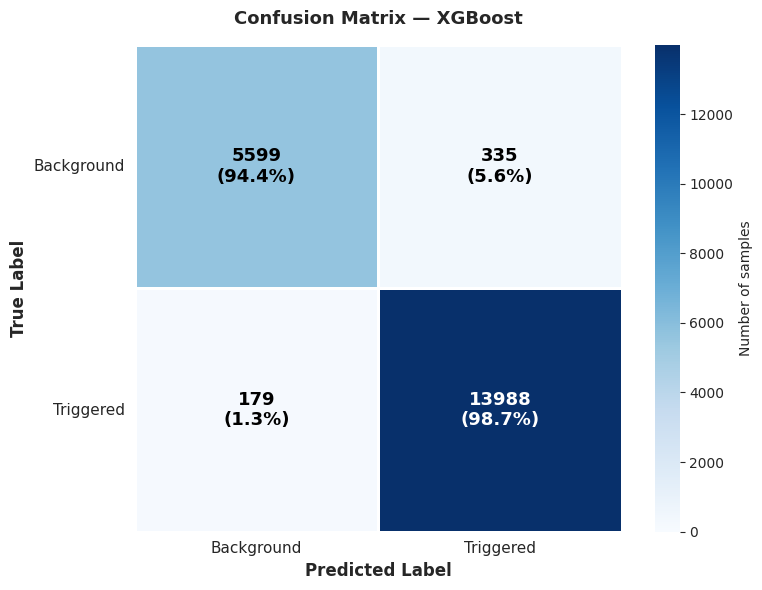

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    confusion_matrix, classification_report,
    accuracy_score, precision_score, recall_score, f1_score
)
import numpy as np

# ============================================
# CONFIGURATION
# ============================================
model_name = "XGBoost Classifier"
labels = ['Background', 'Triggered']  # Adjust automatically if multiclass

plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.size'] = 10
sns.set_style("whitegrid")

# ============================================
# METRIC COMPUTATION
# ============================================
cm = confusion_matrix(y_test, y_test_pred)
is_binary = len(np.unique(y_test)) == 2
average_method = 'binary' if is_binary else 'weighted'

accuracy = accuracy_score(y_test, y_test_pred)
precision = precision_score(y_test, y_test_pred, average=average_method, zero_division=0)
recall = recall_score(y_test, y_test_pred, average=average_method, zero_division=0)
f1 = f1_score(y_test, y_test_pred, average=average_method, zero_division=0)

cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

# ============================================
# CONFUSION MATRIX PLOT
# ============================================
fig, ax = plt.subplots(figsize=(8, 6))

sns.heatmap(cm, annot=False, fmt='d', cmap='Blues',
            xticklabels=labels, yticklabels=labels,
            cbar_kws={'label': 'Number of samples'},
            linewidths=2, linecolor='white',
            square=True, ax=ax, vmin=0)

# Annotate each cell with both counts and percentages
for i in range(len(cm)):
    for j in range(len(cm)):
        count = cm[i, j]
        percentage = cm_normalized[i, j] * 100
        text_color = 'white' if count > cm.max() / 2 else 'black'
        ax.text(j + 0.5, i + 0.5, f'{count}\n({percentage:.1f}%)',
                ha='center', va='center', fontsize=13,
                fontweight='bold', color=text_color)

# ============================================
# LABELS, TITLE, AND METRIC SUMMARY
# ============================================
ax.set_xlabel('Predicted Label', fontsize=12, fontweight='bold')
ax.set_ylabel('True Label', fontsize=12, fontweight='bold')
ax.set_title(f'Confusion Matrix — XGBoost', fontsize=13, fontweight='bold', pad=15)

ax.set_xticklabels(labels, fontsize=11)
ax.set_yticklabels(labels, fontsize=11, rotation=0)




plt.tight_layout()
plt.savefig('600_xgb-confusion_matrix.png', dpi=600, bbox_inches='tight', facecolor='white')
plt.show()


In [22]:
# ============================================================================
# STEP 6: CREATE OUTPUT DIRECTORY AND SAVE RESULTS
# ============================================================================
import os
import joblib
from datetime import datetime

print("\n" + "=" * 80)
print("[STEP 6] Saving Model and Results...")
print("=" * 80)

# ----------------------------------------------------------------------------
# Create output directory with timestamp
# ----------------------------------------------------------------------------

output_dir = f"xgb_model_results"
os.makedirs(output_dir, exist_ok=True)
print(f"✓ Created directory: {output_dir}")



[STEP 6] Saving Model and Results...
✓ Created directory: xgb_model_results


In [23]:

# ----------------------------------------------------------------------------
# Save the trained model
# ----------------------------------------------------------------------------
model_path = os.path.join(output_dir, "gradient_boosting_model.pkl")
joblib.dump(xgb_model, model_path)
print(f"✓ Saved model to: {model_path}")

# ----------------------------------------------------------------------------
# Save label encoder (if used)
# ----------------------------------------------------------------------------
if le is not None:
    le_path = os.path.join(output_dir, "xgb_label_encoder.pkl")
    joblib.dump(le, le_path)
    print(f"✓ Saved label encoder to: {le_path}")

# ----------------------------------------------------------------------------
# Save feature names
# ----------------------------------------------------------------------------
feature_names_path = os.path.join(output_dir, "xgb-feature_names.pkl")
joblib.dump(feature_cols, feature_names_path)
print(f"✓ Saved feature names to: {feature_names_path}")

# ----------------------------------------------------------------------------
# Save model metrics summary
# ----------------------------------------------------------------------------
metrics_path = os.path.join(output_dir, "xgb_model_metrics.txt")
with open(metrics_path, 'w') as f:
    f.write("EARTHQUAKE GRADIENT BOOSTING MODEL - PERFORMANCE METRICS\n")
    f.write("=" * 70 + "\n\n")
    f.write(f"Training samples: {X_train.shape[0]}\n")
    f.write(f"Test samples: {X_test.shape[0]}\n")
    f.write(f"Number of features: {X_train.shape[1]}\n\n")

    f.write("PERFORMANCE METRICS:\n")
    f.write("-" * 70 + "\n")
    f.write(f"Training Accuracy:        {train_accuracy:.4f}\n")
    f.write(f"Test Accuracy:            {test_accuracy:.4f}\n")
    f.write(f"Precision:                {precision:.4f}\n")
    f.write(f"Recall:                   {recall:.4f}\n")
    f.write(f"F1 Score:                 {f1:.4f}\n")
    f.write(f"Cross-Val Accuracy:       {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})\n\n")

    f.write("CLASSIFICATION REPORT:\n")
    f.write("-" * 70 + "\n")
    f.write(classification_report(y_test, y_test_pred, target_names=target_names))
    f.write("\n\nCONFUSION MATRIX:\n")
    f.write("-" * 70 + "\n")
    f.write(str(cm))

print(f"✓ Saved metrics to: {metrics_path}")

# ----------------------------------------------------------------------------
# Save predictions
# ----------------------------------------------------------------------------
predictions_df = pd.DataFrame({
    'True_Label': y_test.values,
    'Predicted_Label': y_test_pred
})

if le is not None:
    predictions_df['True_Label_Name'] = le.inverse_transform(y_test.values)
    predictions_df['Predicted_Label_Name'] = le.inverse_transform(y_test_pred)

predictions_path = os.path.join(output_dir, "xgb_test_predictions.csv")
predictions_df.to_csv(predictions_path, index=False)
print(f"✓ Saved predictions to: {predictions_path}")

# ----------------------------------------------------------------------------
# Optional: save confusion matrix image (if already plotted)
# ----------------------------------------------------------------------------
confmat_path = os.path.join(output_dir, "xgb_confusion_matrix.png")
plt.savefig(confmat_path, dpi=300, bbox_inches='tight', facecolor='white')
print(f"✓ Saved confusion matrix plot to: {confmat_path}")

print("\n✅ All model artifacts and results successfully saved!")
print("=" * 80)


✓ Saved model to: xgb_model_results/gradient_boosting_model.pkl
✓ Saved label encoder to: xgb_model_results/xgb_label_encoder.pkl
✓ Saved feature names to: xgb_model_results/xgb-feature_names.pkl
✓ Saved metrics to: xgb_model_results/xgb_model_metrics.txt
✓ Saved predictions to: xgb_model_results/xgb_test_predictions.csv
✓ Saved confusion matrix plot to: xgb_model_results/xgb_confusion_matrix.png

✅ All model artifacts and results successfully saved!


<Figure size 1200x800 with 0 Axes>


[STEP 7] Creating Visualizations...
✓ Saved performance plots to: xgb_model_results/xgb_model_performance_plots_gb.png


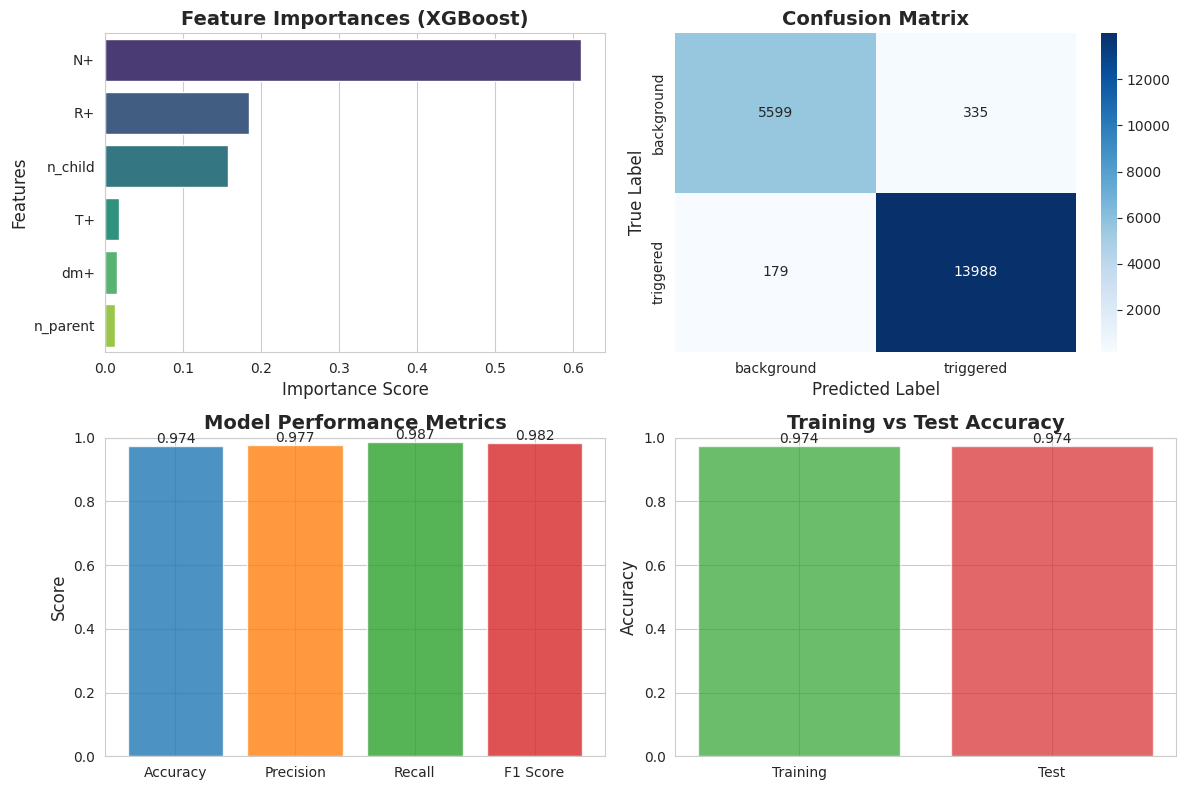

\ Important Features:


,feature,importance
0,N+,0.610705
1,R+,0.184259
2,n_child,0.157846
3,T+,0.018854
4,dm+,0.015064
5,n_parent,0.013272



✓ Saved detailed feature importance plot to:
  /home/ashraf/Desktop/THESIS-FINAL/ML-pipeline/XGB/XGB_Feature_Importance_Detailed.png


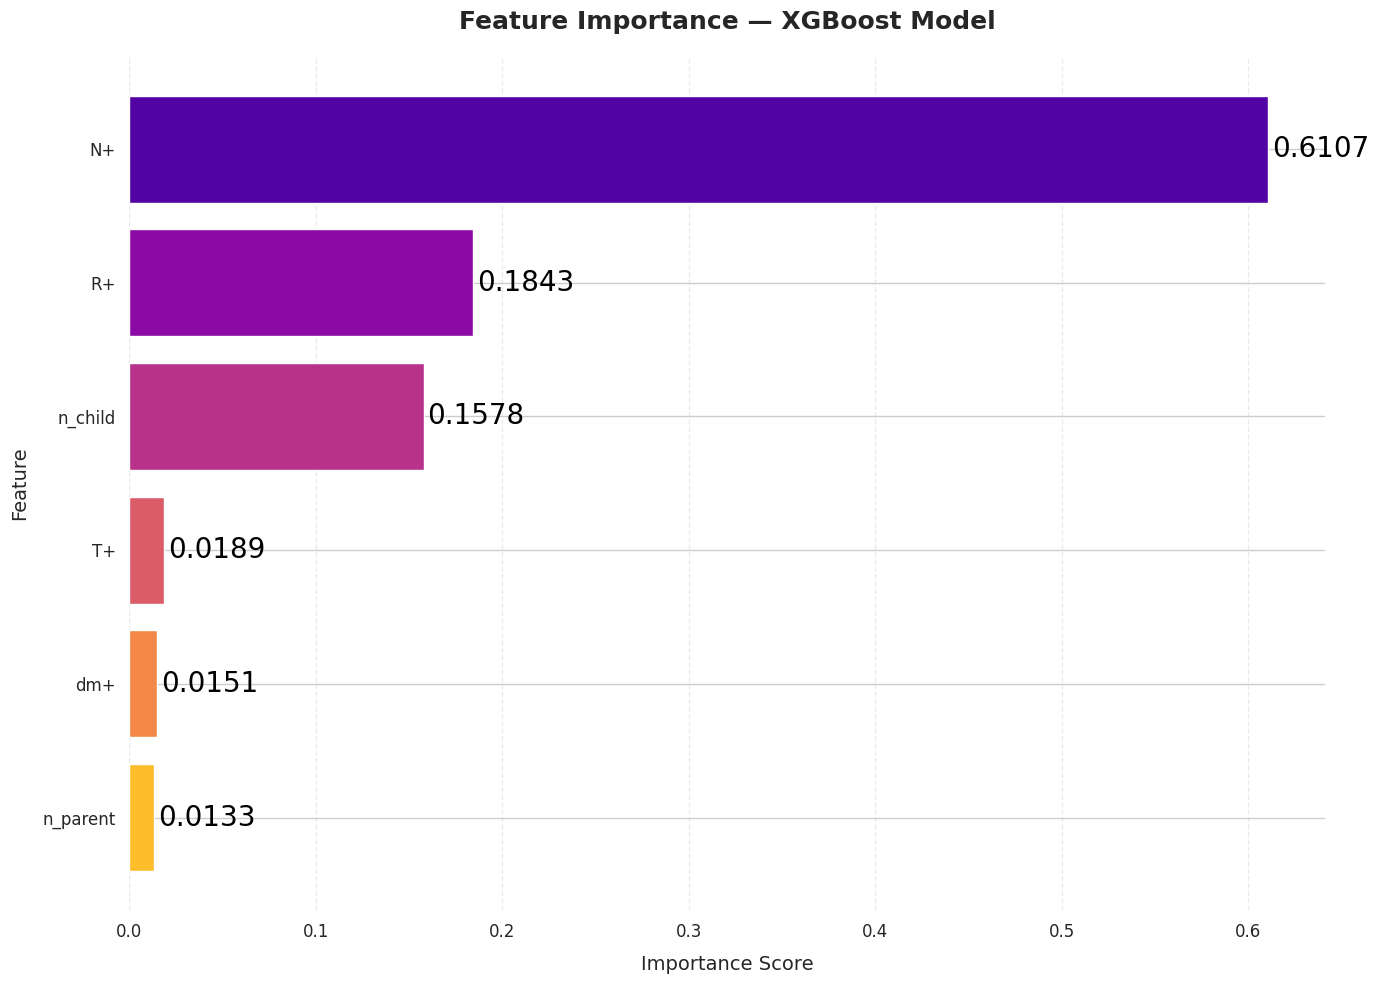

✓ Saved feature importance data to: /home/ashraf/Desktop/THESIS-FINAL/ML-pipeline/XGB/feature_importance_Xgb.csv


In [24]:
# ============================================================================
# STEP 7: VISUALIZATIONS
# ============================================================================
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
import os

print("\n" + "=" * 80)
print("[STEP 7] Creating Visualizations...")
print("=" * 80)

# ----------------------------------------------------------------------------
# 1. Feature Importance Plot
# ----------------------------------------------------------------------------
plt.figure(figsize=(12, 8))

# Feature importances from Gradient Boosting
feature_importance = pd.DataFrame({
    'feature': feature_cols,
    'importance': xgb_model.feature_importances_
}).sort_values('importance', ascending=False)

plt.subplot(2, 2, 1)
sns.barplot(data=feature_importance.head(20), x='importance', y='feature', palette='viridis')
plt.title('Feature Importances (XGBoost)', fontsize=14, fontweight='bold')
plt.xlabel('Importance Score', fontsize=12)
plt.ylabel('Features', fontsize=12)

# ----------------------------------------------------------------------------
# 2. Confusion Matrix Heatmap
# ----------------------------------------------------------------------------
plt.subplot(2, 2, 2)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=target_names, yticklabels=target_names)
plt.title('Confusion Matrix', fontsize=14, fontweight='bold')
plt.ylabel('True Label', fontsize=12)
plt.xlabel('Predicted Label', fontsize=12)

# ----------------------------------------------------------------------------
# 3. Model Performance Comparison
# ----------------------------------------------------------------------------
plt.subplot(2, 2, 3)
metrics_data = {
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1 Score'],
    'Score': [test_accuracy, precision, recall, f1]
}
metrics_df = pd.DataFrame(metrics_data)
bars = plt.bar(metrics_df['Metric'], metrics_df['Score'], 
               color=['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728'], alpha=0.8)
plt.ylim(0, 1)
plt.title('Model Performance Metrics', fontsize=14, fontweight='bold')
plt.ylabel('Score', fontsize=12)
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
             f'{height:.3f}', ha='center', va='bottom', fontsize=10)

# ----------------------------------------------------------------------------
# 4. Training vs Test Accuracy
# ----------------------------------------------------------------------------
plt.subplot(2, 2, 4)
accuracy_comparison = pd.DataFrame({
    'Dataset': ['Training', 'Test'],
    'Accuracy': [train_accuracy, test_accuracy]
})
bars = plt.bar(accuracy_comparison['Dataset'], accuracy_comparison['Accuracy'],
               color=['#2ca02c', '#d62728'], alpha=0.7)
plt.ylim(0, 1)
plt.title('Training vs Test Accuracy', fontsize=14, fontweight='bold')
plt.ylabel('Accuracy', fontsize=12)
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
             f'{height:.3f}', ha='center', va='bottom', fontsize=10)

# ----------------------------------------------------------------------------
# Save combined performance visualization
# ----------------------------------------------------------------------------
plt.tight_layout()
plot_path = os.path.join(output_dir, "xgb_model_performance_plots_gb.png")
plt.savefig(plot_path, dpi=300, bbox_inches='tight', facecolor='white')
print(f"✓ Saved performance plots to: {plot_path}")
plt.show()

# ----------------------------------------------------------------------------
# 5. Detailed Feature Importance Plot
# ----------------------------------------------------------------------------
# Create feature importance DataFrame
feature_importance = pd.DataFrame({
    'feature': X.columns,
    'importance': xgb_model.feature_importances_
}).sort_values(by='importance', ascending=False).reset_index(drop=True)

# Optional: display top features in console
print("\ Important Features:")
display(feature_importance.head(10))

# -----------------------------
# BEAUTIFUL HORIZONTAL BAR PLOT
# -----------------------------
plt.figure(figsize=(14, 10))
sns.set(style="whitegrid")

bars = plt.barh(
    y=feature_importance['feature'],
    width=feature_importance['importance'],
    color=sns.color_palette("plasma", len(feature_importance))
)

# Add importance values next to bars
for bar in bars:
    width = bar.get_width()
    plt.text(
        width + 0.002,               # Slight offset
        bar.get_y() + bar.get_height() / 2,
        f"{width:.4f}",              # Display up to 4 decimal places
        ha='left', va='center', fontsize=20, color='black'
    )

# Title and labels
plt.title("Feature Importance — XGBoost Model", fontsize=18, fontweight='bold', pad=20)
plt.xlabel("Importance Score", fontsize=14, labelpad=10)
plt.ylabel("Feature", fontsize=14, labelpad=10)

# Aesthetic tweaks
plt.gca().invert_yaxis()  # Highest importance at top
plt.grid(axis='x', linestyle='--', alpha=0.4)
plt.tick_params(axis='both', which='major', labelsize=12)
sns.despine(left=True, bottom=True)

# Tight layout and save figure
plt.tight_layout()

# Define output directory and save file
output_dir = os.getcwd()
feat_imp_path = os.path.join(output_dir, "XGB_Feature_Importance_Detailed.png")
plt.savefig(feat_imp_path, dpi=300, bbox_inches='tight', facecolor='white')

# Display and confirm save
print(f"\n✓ Saved detailed feature importance plot to:\n  {feat_imp_path}")
plt.show()

# ----------------------------------------------------------------------------
# 6. Save feature importance data to CSV
# ----------------------------------------------------------------------------
feat_imp_csv = os.path.join(output_dir, "feature_importance_Xgb.csv")
feature_importance.to_csv(feat_imp_csv, index=False)
print(f"✓ Saved feature importance data to: {feat_imp_csv}")


# APPLY MODEL TO Real catalog DATA

In [34]:

new_data_file = "/home/ashraf/Desktop/THESIS-FINAL/TRAIN-DATA/mld_final-nz_real_catalog.csv"  # Replace with your new data file
new_df = pd.read_csv(new_data_file)
new_df.head()

,event,date,Time,latitude,longitude,depth,magnitude,DateTime,time,Year,...,Hour,Minute,Second,i+,N+,T+,R+,dm+,n_child,n_parent
0,2,1980-01-01,09:27:04.52,-40.490,174.66901,72.6,3.200,1980-01-01 09:27:04.520,0.099293,1980,...,9,27,4.52,0,0.000217,0.004731,0.045941,-0.633,0.082958,0.041479
1,3,1980-01-01,18:28:10.99,-37.630,176.38000,210.0,4.150,1980-01-01 18:28:10.990,0.475062,1980,...,18,28,10.99,1,0.001304,0.008451,0.154341,-0.950,0.124437,0.082958
2,4,1980-01-01,20:20:54.03,-40.290,173.42999,212.0,4.500,1980-01-01 20:20:54.030,0.553338,1980,...,20,20,54.03,2,0.000038,0.000571,0.066251,-0.350,0.165915,0.124437
3,5,1980-01-02,18:24:15.40,-38.480,176.75000,5.0,3.375,1980-01-02 18:24:15.400,1.472336,1980,...,18,24,15.40,2,0.000047,0.007270,0.006458,0.775,0.000000,0.124437
4,6,1980-01-04,01:21:41.06,-40.906,175.23700,24.1,2.750,1980-01-04 01:21:41.060,2.762216,1980,...,1,21,41.06,3,0.000144,0.010633,0.013547,1.750,0.041479,0.165915



[STEP 8] Applying Model to New Dataset...

Attempting to load: /home/ashraf/Desktop/THESIS-FINAL/TRAIN-DATA/mld_final-nz_real_catalog.csv
✓ New data loaded successfully!
  Shape: (396267, 22)

🔍 Making predictions on new data...
✓ Saved new predictions to: /home/ashraf/Desktop/THESIS-FINAL/ML-pipeline/XGB/xgb_real_data_predictions_gb.csv

Real DATA PREDICTION SUMMARY
Total predictions made: 396267

background    230758
triggered     165509
Name: count, dtype: int64


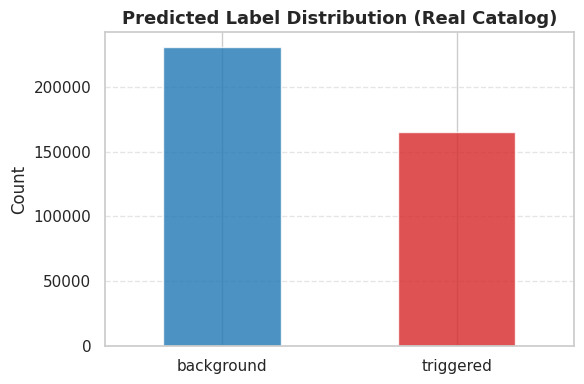

✓ Saved prediction distribution plot to: /home/ashraf/Desktop/THESIS-FINAL/ML-pipeline/XGB/real_data_prediction_distribution_xgb.png

import joblib
import pandas as pd

# Load saved model components
model = joblib.load('path/to/gradient_boosting_model.pkl')
features = joblib.load('path/to/feature_names.pkl')
encoder = joblib.load('path/to/label_encoder.pkl')

# Load new dataset and make predictions
new_data = pd.read_csv('path/to/new_data.csv')
new_predictions = model.predict(new_data[features])
predicted_labels = encoder.inverse_transform(new_predictions)



In [25]:
# ============================================================================
# STEP 8: APPLY MODEL TO NEW DATA
# ============================================================================
import pandas as pd
import os
import numpy as np
from datetime import datetime

print("\n" + "=" * 80)
print("[STEP 8] Applying Model to New Dataset...")
print("=" * 80)

# ----------------------------------------------------------------------------
# Load new dataset (replace path as needed)
# ----------------------------------------------------------------------------
new_data_file = "/home/ashraf/Desktop/THESIS-FINAL/TRAIN-DATA/mld_final-nz_real_catalog.csv"  # <-- update if needed

try:
    print(f"\nAttempting to load: {new_data_file}")
    new_df = pd.read_csv(new_data_file)
    print(f"✓ New data loaded successfully!")
    print(f"  Shape: {new_df.shape}")
    
    # ----------------------------------------------------------------------------
    # Match features with those used in training
    # ----------------------------------------------------------------------------
    missing_features = [f for f in feature_cols if f not in new_df.columns]
    if missing_features:
        print(f"\n⚠ Missing features in new data: {missing_features}")
        print("  ➜ Filling missing features with 0s for consistency.")
        for feat in missing_features:
            new_df[feat] = 0

    # Ensure correct feature order
    X_new = new_df[feature_cols]

    # Handle missing values
    if X_new.isnull().sum().sum() > 0:
        print(f"⚠ Handling {X_new.isnull().sum().sum()} missing values in new data...")
        X_new = X_new.fillna(X_new.median())

    # ----------------------------------------------------------------------------
    # Make predictions
    # ----------------------------------------------------------------------------
    print("\n🔍 Making predictions on new data...")
    y_new_pred = xgb_model.predict(X_new)
    y_new_proba = xgb_model.predict_proba(X_new)

    results_df = new_df.copy()
    results_df['Predicted_Label'] = y_new_pred

    # If label encoder was used
    if le is not None:
        results_df['Predicted_Label_Name'] = le.inverse_transform(y_new_pred)

    # Add probability columns for each class
    for i, class_name in enumerate(target_names):
        results_df[f'Probability_{class_name}'] = y_new_proba[:, i]

    # ----------------------------------------------------------------------------
    # Save new predictions
    # ----------------------------------------------------------------------------
    new_predictions_path = os.path.join(output_dir, "xgb_real_data_predictions_gb.csv")
    results_df.to_csv(new_predictions_path, index=False)
    print(f"✓ Saved new predictions to: {new_predictions_path}")

    # ----------------------------------------------------------------------------
    # Print summary
    # ----------------------------------------------------------------------------
    print("\n" + "=" * 50)
    print("Real DATA PREDICTION SUMMARY")
    print("=" * 50)
    print(f"Total predictions made: {len(y_new_pred)}\n")

    # Prediction label distribution
    if le is not None:
        pred_counts = pd.Series(le.inverse_transform(y_new_pred)).value_counts()
    else:
        pred_counts = pd.Series(y_new_pred).value_counts()

    print(pred_counts)

    # Optional: visualize prediction distribution
    plt.figure(figsize=(6, 4))
    pred_counts.plot(kind='bar', color=['#1f77b4', '#d62728'], alpha=0.8)
    plt.title('Predicted Label Distribution (Real Catalog)', fontsize=13, fontweight='bold')
    plt.ylabel('Count')
    plt.xticks(rotation=0)
    plt.grid(axis='y', linestyle='--', alpha=0.5)
    plt.tight_layout()
    pred_dist_path = os.path.join(output_dir, "real_data_prediction_distribution_xgb.png")
    plt.savefig(pred_dist_path, dpi=300, bbox_inches='tight', facecolor='white')
    plt.show()
    print(f"✓ Saved prediction distribution plot to: {pred_dist_path}")

except FileNotFoundError:
    print(f"\n⚠ File '{new_data_file}' not found.")
    print("  To use the model on new data:")
    print("  1️⃣ Prepare a CSV file with the same feature columns as training data")
    print("  2️⃣ Update the 'new_data_file' variable with your file path")
    print("  3️⃣ Re-run this cell")
except Exception as e:
    print(f"\n❌ Error processing new data: {str(e)}")

print("""
import joblib
import pandas as pd

# Load saved model components
model = joblib.load('path/to/gradient_boosting_model.pkl')
features = joblib.load('path/to/feature_names.pkl')
encoder = joblib.load('path/to/label_encoder.pkl')

# Load new dataset and make predictions
new_data = pd.read_csv('path/to/new_data.csv')
new_predictions = model.predict(new_data[features])
predicted_labels = encoder.inverse_transform(new_predictions)
""")


In [26]:
print("\n=== PREDICTION SUMMARY ===")

# Distribution of predicted labels
pred_counts = results_df['Predicted_Label'].value_counts()
total = pred_counts.sum()

print("\nPredicted Label Distribution:")
for label, count in pred_counts.items():
    percent = (count / total) * 100
    label_name = le.inverse_transform([label])[0] if le else label
    print(f"  {label_name}: {count} ({percent:.2f}%)")

# Average model confidence per class
if 'Probability_background' in results_df.columns:
    prob_cols = [c for c in results_df.columns if c.startswith('Probability_')]
    avg_confidence = results_df[prob_cols].mean()
    print("\nAverage Confidence per Class:")
    print(avg_confidence)



=== PREDICTION SUMMARY ===

Predicted Label Distribution:
  background: 230758 (58.23%)
  triggered: 165509 (41.77%)

Average Confidence per Class:
Probability_background    0.616316
Probability_triggered     0.383684
dtype: float32


# ROC-ACCURACY

ROC-AUC Score: 0.9974


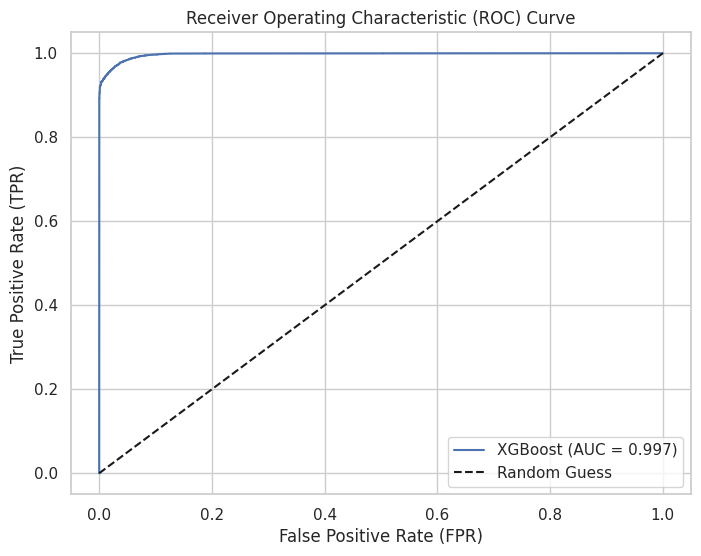

In [32]:
from sklearn.metrics import roc_auc_score, roc_curve
import matplotlib.pyplot as plt

# Predict probabilities
y_pred_proba = xgb_best.predict_proba(X_test_scaled)[:, 1]  # take probability of class 1

# Compute ROC-AUC score
roc_auc = roc_auc_score(y_test, y_pred_proba)
print(f"ROC-AUC Score: {roc_auc:.4f}")

# Compute ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)

# Plot ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'XGBoost (AUC = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], 'k--', label='Random Guess')
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend()
plt.grid(True)
plt.show()


# Plot from Prediction data

In [27]:
prediction_data=pd.read_csv("/home/ashraf/Desktop/THESIS-FINAL/ML-pipeline/XGB/xgb_real_data_predictions_gb.csv")
prediction_data.head()

,event,date,Time,latitude,longitude,depth,magnitude,DateTime,time,Year,...,N+,T+,R+,dm+,n_child,n_parent,Predicted_Label,Predicted_Label_Name,Probability_background,Probability_triggered
0,2,1980-01-01,09:27:04.52,-40.490,174.66901,72.6,3.200,1980-01-01 09:27:04.520,0.099293,1980,...,0.000217,0.004731,0.045941,-0.633,0.082958,0.041479,0,background,0.998189,0.001811
1,3,1980-01-01,18:28:10.99,-37.630,176.38000,210.0,4.150,1980-01-01 18:28:10.990,0.475062,1980,...,0.001304,0.008451,0.154341,-0.950,0.124437,0.082958,0,background,0.997997,0.002003
2,4,1980-01-01,20:20:54.03,-40.290,173.42999,212.0,4.500,1980-01-01 20:20:54.030,0.553338,1980,...,0.000038,0.000571,0.066251,-0.350,0.165915,0.124437,0,background,0.989898,0.010102
3,5,1980-01-02,18:24:15.40,-38.480,176.75000,5.0,3.375,1980-01-02 18:24:15.400,1.472336,1980,...,0.000047,0.007270,0.006458,0.775,0.000000,0.124437,0,background,0.952895,0.047105
4,6,1980-01-04,01:21:41.06,-40.906,175.23700,24.1,2.750,1980-01-04 01:21:41.060,2.762216,1980,...,0.000144,0.010633,0.013547,1.750,0.041479,0.165915,1,triggered,0.263873,0.736127


# Gaussian Mixture Model method

📂 Loading: /home/ashraf/Desktop/THESIS-FINAL/ML-pipeline/XGB/xgb_real_data_predictions_gb.csv
📊 Background events: 233248 | Aftershock events: 155762
📈 GMM Params: μ1=-7.59, μ2=-4.96, σ1=1.26, σ2=0.61, threshold=5.99e-07
✅ Plot saved as ENTIRE_NZ_gmm_XGB_predictions_landscape.png


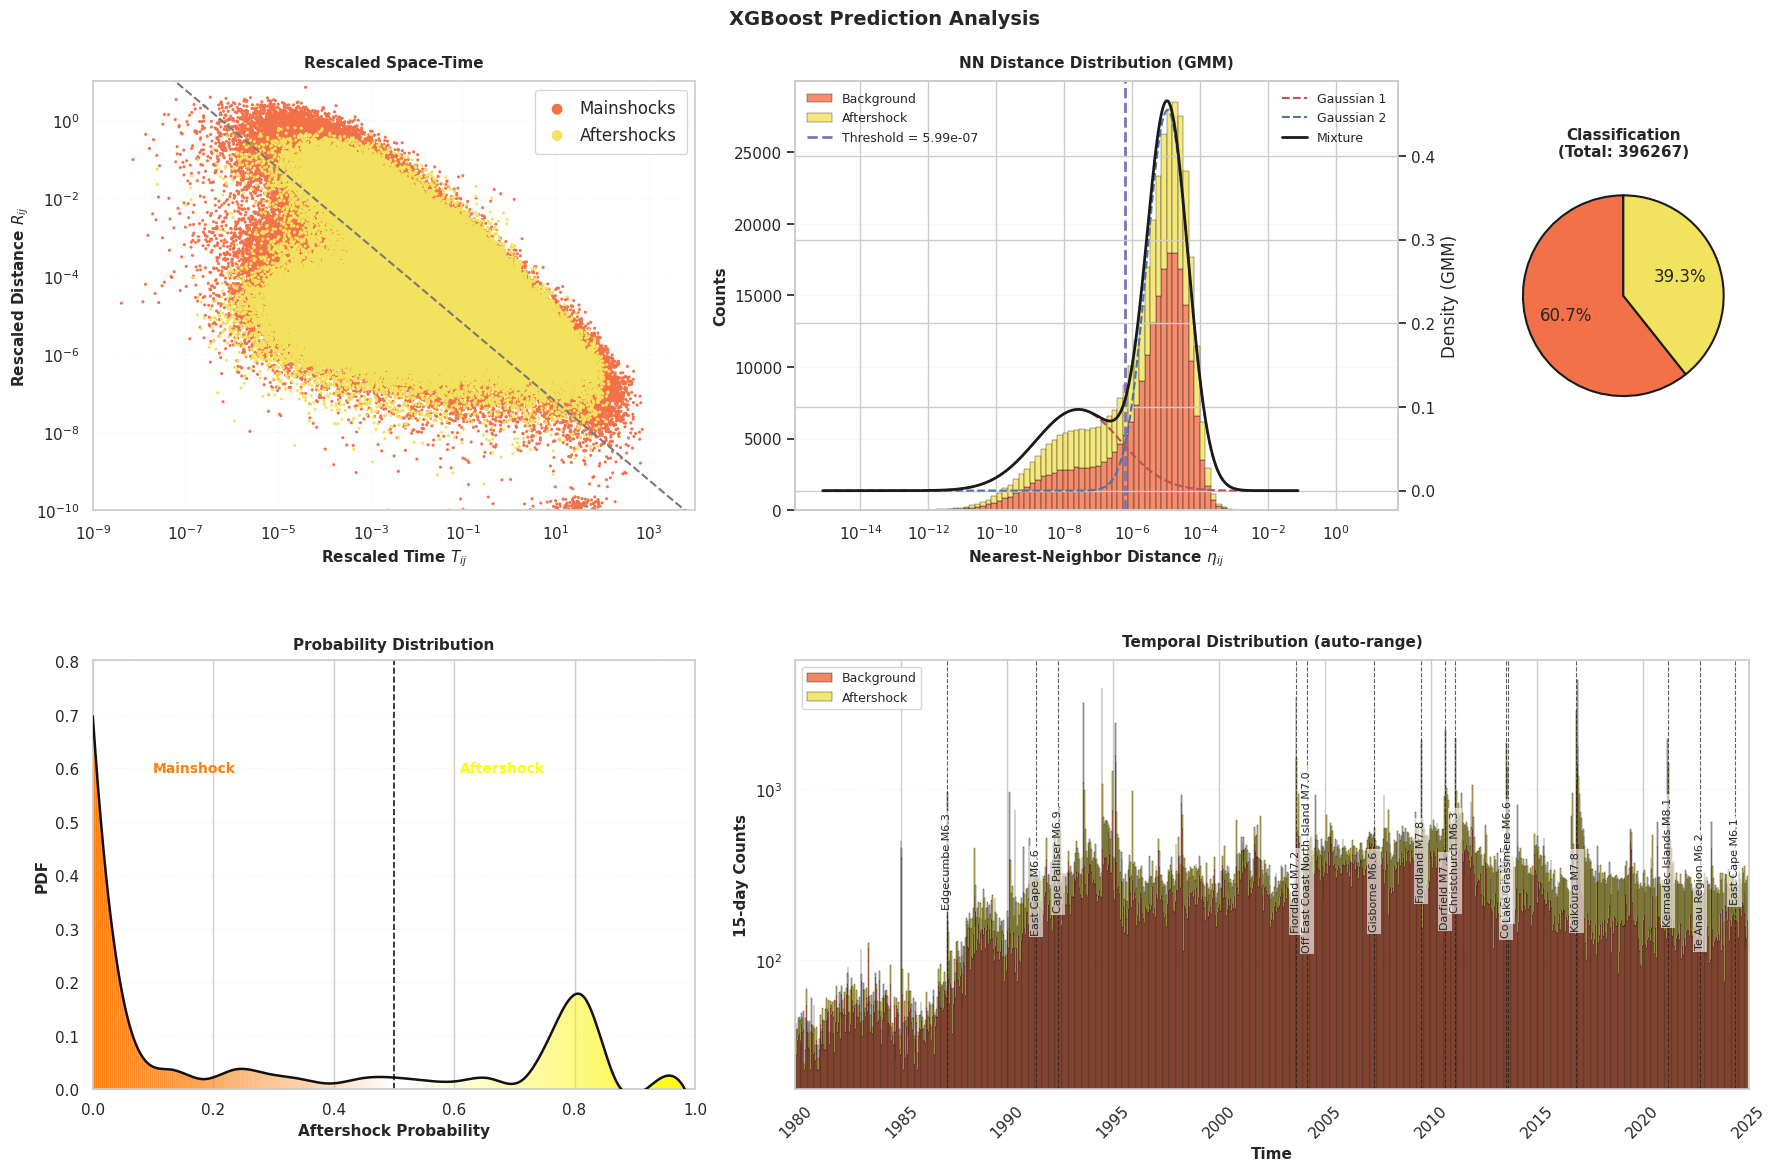

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as md
import matplotlib.colors as mc
from scipy.stats import norm
from sklearn.mixture import GaussianMixture
from matplotlib.font_manager import FontProperties
import warnings
warnings.filterwarnings('ignore')

# -----------------------
# Configuration
# -----------------------
CONFIG = {
    'figure_size': (18, 12),  
    'dpi': 300,
    'colors': {
        'mainshock': '#f27149',
        'aftershock': "#ffef5b",
        'boundary': '#787878',
        'text': '#606060'
    },
    'scatter_size': 5,
    'weibull_bins': 100,
    'prob_bins': 20
}

# -----------------------
# Major historical earthquakes (New Zealand)
# -----------------------
MAJOR_EVENTS_NZ = {
    '1987-03-02': 'Edgecumbe M6.3',
    '1991-05-13': 'East Cape M6.6',
    '1992-05-19': 'Cape Palliser M6.9',
    '2003-08-22': 'Fiordland M7.2',
    '2004-02-21': 'Off East Coast North Island M7.0',
    '2007-04-30': 'Gisborne M6.6',
    '2009-07-15': 'Fiordland M7.8',
    '2010-09-04': 'Darfield M7.1',
    '2011-02-22': 'Christchurch M6.3',
    '2013-07-21': 'Cook Strait M6.5',
    '2013-08-16': 'Lake Grassmere M6.6',
    '2016-11-14': 'Kaikōura M7.8',
    '2021-03-05': 'Kermadec Islands M8.1',
    '2022-09-10': 'Te Anau Region M6.2',
    '2024-04-30': 'East Cape M6.1'
}

# -----------------------
# Data Processing
# -----------------------
def load_and_validate_data(prediction_csv):
    """Load CSV and validate required columns."""
    print(f"📂 Loading: {prediction_csv}")
    df = pd.read_csv(prediction_csv)
    
    prob_col = next((c for c in df.columns if "Probability" in c and "triggered" in c), None)
    if prob_col is None:
        raise ValueError("❌ No aftershock probability column found.")
    
    if 'N+' not in df.columns:
        raise ValueError("❌ Column 'N+' not found!")
    
    return df, prob_col

def extract_populations(df, prob_col):
    """Extract mainshock and aftershock populations."""
    prob = df[prob_col].values
    pred = np.round(prob)
    
    main_N = df.loc[pred == 0, 'N+'][df.loc[pred == 0, 'N+'] > 0]
    after_N = df.loc[pred == 1, 'N+'][df.loc[pred == 1, 'N+'] > 0]
    
    print(f"📊 Background events: {len(main_N)} | Aftershock events: {len(after_N)}")
    return prob, pred, main_N, after_N

# -----------------------
# Plotting Functions
# -----------------------

def plot_scatter(ax, df, pred, prob):
    """Plot scatter (T+ vs R+)."""
    colors = CONFIG['colors']
    
    if not {'T+', 'R+'}.issubset(df.columns):
        ax.text(0.5, 0.5, 'T+ or R+ not available', ha='center', va='center', 
                transform=ax.transAxes, fontsize=12)
        return
    
    cmap_main = mc.LinearSegmentedColormap.from_list(
        'main', [(0, (*mc.to_rgb(colors['mainshock']), 0)), (1, colors['mainshock'])]
    )
    cmap_after = mc.LinearSegmentedColormap.from_list(
        'after', [(0, (*mc.to_rgb(colors['aftershock']), 0)), (1, colors['aftershock'])]
    )
    
    ax.scatter(df.loc[pred == 0, 'T+'], df.loc[pred == 0, 'R+'],
               s=CONFIG['scatter_size'], c=1 - prob[pred == 0], 
               cmap=cmap_main, ec='None', alpha=.99, label='Mainshocks')
    ax.scatter(df.loc[pred == 1, 'T+'], df.loc[pred == 1, 'R+'],
               s=CONFIG['scatter_size'], c=prob[pred == 1], 
               cmap=cmap_after, ec='None', alpha=0.99, label='Aftershocks')
    
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_xlim(1e-9, 1e4)
    ax.set_ylim(1e-10, 10)
    ax.set_xlabel(r'Rescaled Time $T_{ij}$', fontsize=11, fontweight='bold')
    ax.set_ylabel(r'Rescaled Distance $R_{ij}$', fontsize=11, fontweight='bold')
    #ax.legend(frameon=True, loc='upper right', fontsize=12)
    ax.legend(
     frameon=True,
     loc='upper right',
     fontsize=12,           # ← Increased font size
     markerscale=3.5,       # ← Enlarge legend marker size
     handlelength=1.5,
     handletextpad=0.6,
     borderpad=0.6
    )
    ax.grid(True, alpha=0.3, linestyle=':', linewidth=0.5)
    ax.set_title('Rescaled Space-Time', fontsize=11, fontweight='bold', pad=10)
    
    # Separation boundary
    threshold = 5.99e-07
    tij = np.array([1e-9, 1e4], dtype=float)
    rij = threshold / tij
    ax.plot(tij, rij, '--', c=colors['boundary'], linewidth=1.5, zorder=10)

# -----------------------
# HISTOGRAM OF N+ WITH GMM
# -----------------------
def plot_histogram(ax, df, pred):
    """Plot histogram of N+ using Gaussian Mixture Model."""
    colors = CONFIG['colors']
    
    # --- Prepare log data ---
    valid = df['N+'] > 0
    log_eta = np.log10(df.loc[valid, 'N+'].values).reshape(-1, 1)
    
    # --- Fit 2-component GMM ---
    gmm = GaussianMixture(n_components=2, random_state=0)
    gmm.fit(log_eta)
    
    means = gmm.means_.flatten()
    stds = np.sqrt(gmm.covariances_).flatten()
    weights = gmm.weights_.flatten()
    order = np.argsort(means)
    mu1, mu2 = means[order]
    sigma1, sigma2 = stds[order]
    w1, w2 = weights[order]

    x = np.linspace(log_eta.min(), log_eta.max(), 2000)
    pdf1 = w1 * norm.pdf(x, mu1, sigma1)
    pdf2 = w2 * norm.pdf(x, mu2, sigma2)
    mixture = pdf1 + pdf2

    # --- Intersection threshold ---
    threshold_idx = np.argwhere(np.diff(np.sign(pdf1 - pdf2))).flatten()
    threshold = x[threshold_idx][0] if len(threshold_idx) > 0 else None

    # --- Plot histogram for both background/aftershock ---
    ax.hist([df.loc[pred == 0, 'N+'], df.loc[pred == 1, 'N+']],
            bins=10 ** np.linspace(-15, 1, 100),
            stacked=True, color=[colors['mainshock'], colors['aftershock']],
            label=['Background', 'Aftershock'], edgecolor='black', linewidth=0.3, alpha=0.8)

    # --- Overlay GMM fits ---
    # --- Clip the PDF domain to the observed η range ---
    x_eta = 10 ** x
    mask = (x_eta >= df['N+'].min()) & (x_eta <= df['N+'].max())
    ax2 = ax.twinx()
    ax2.plot(x_eta[mask], pdf1[mask], 'r--', lw=1.5, label='Gaussian 1')
    ax2.plot(x_eta[mask], pdf2[mask], 'b--', lw=1.5, label='Gaussian 2')
    ax2.plot(x_eta[mask], mixture[mask], 'k-', lw=2, label='Mixture')
    
    # ax2 = ax.twinx()
    # ax2.plot(10 ** x, pdf1, 'r--', lw=1.5, label='Gaussian 1')
    # ax2.plot(10 ** x, pdf2, 'b--', lw=1.5, label='Gaussian 2')
    # ax2.plot(10 ** x, mixture, 'k-', lw=2, label='Mixture')

    if threshold is not None:
        ax.axvline(10 ** threshold, ls='--', c='m', lw=2,
                   label=f'Threshold = {10 ** threshold:.2e}')

    # --- Styling -
    ax.set_xscale('log')
    ax.set_xlabel(r'Nearest-Neighbor Distance $\eta_{ij}$', fontsize=11, fontweight='bold')
    ax.set_ylabel('Counts', fontsize=11, fontweight='bold')
    ax2.set_ylabel('Density (GMM)')
    ax.legend(frameon=False, fontsize=9, loc='upper left')
    ax2.legend(frameon=False, fontsize=9, loc='upper right')
    ax.grid(True, alpha=0.3, axis='y', linestyle=':')
    ax.set_title('NN Distance Distribution (GMM)', fontsize=11, fontweight='bold', pad=10)
    
    print(f"📈 GMM Params: μ1={mu1:.2f}, μ2={mu2:.2f}, σ1={sigma1:.2f}, σ2={sigma2:.2f}, threshold={10**threshold:.2e}")

# -----------------------
# Other Plots (Probability, Temporal, Pie)
# -----------------------
# def plot_probability_distribution(ax, prob):
    # colors = CONFIG['colors']
    # h, bins_prob = np.histogram(prob, bins=np.linspace(0, 1, CONFIG['prob_bins']))
    # h = h / h.sum()
    # bins_prob = bins_prob[:-1]
    # 
    # ax.plot(bins_prob, h, c=colors['text'], linewidth=2)
    # for i in range(len(bins_prob) - 1):
        # b = bins_prob[i:i + 2]; h_ = h[i:i + 2]
        # color = colors['mainshock'] if b[0] <= 0.5 else colors['aftershock']
        # alpha = 1 - abs(b[0] - 0.5) * 2
        # ax.fill_between(b, h_, fc=color, alpha=alpha * 1.0)
    # ax.axvline(0.5, linestyle='--', color='k', linewidth=1.0)
    # ax.set_xlim(0, 1)
    # ax.set_xlabel('Aftershock Probability', fontsize=11, fontweight='bold')
    # ax.set_ylabel('PDF', fontsize=11, fontweight='bold')
    # ax.grid(True, alpha=0.3, axis='y', linestyle=':')
    # ax.set_title('Probability Distribution', fontsize=11, fontweight='bold')
import numpy as np
import matplotlib.colors as mcolors
import matplotlib.pyplot as plt
from scipy.interpolate import make_interp_spline

def plot_probability_distribution(ax, prob):
    """Smooth probability distribution with fading orange→yellow transition."""
    
    # Define key colors
    color_main = '#ff7f0e'   # orange (mainshock side)
    color_after = '#fff700'  # bright yellow (aftershock side)
    boundary_color = '#111111'

    # Compute normalized histogram
    h, bins = np.histogram(prob, bins=np.linspace(0, 1, CONFIG['prob_bins']))
    h = h / h.sum()
    centers = (bins[:-1] + bins[1:]) / 2

    # Smooth curve for better appearance
    smooth_x = np.linspace(0, 1, 300)
    spline = make_interp_spline(centers, h, k=3)
    smooth_y = spline(smooth_x)

    # Create base gradient colormap (orange → yellow)
    cmap = mcolors.LinearSegmentedColormap.from_list("orange_yellow", [color_main, color_after])

    # Fill region with fading color based on probability
    for i in range(len(smooth_x) - 1):
        x0, x1 = smooth_x[i], smooth_x[i + 1]
        y0, y1 = smooth_y[i], smooth_y[i + 1]

        # Compute color transition factor
        if x0 < 0.5:
            # Left side: orange fades out
            fade = 1 - (x0 / 0.5) ** 1.2     # nonlinear smooth fade
            color = mcolors.to_rgba(color_main, alpha=fade)
        else:
            # Right side: yellow fades in
            grow = ((x0 - 0.5) / 0.5) ** 1.2
            color = mcolors.to_rgba(color_after, alpha=grow)

        ax.fill_between([x0, x1], [y0, y1], color=color, linewidth=0)

    # Draw boundary curve
    ax.plot(smooth_x, smooth_y, color=boundary_color, lw=1.8, zorder=5)

    # Add vertical threshold line
    ax.axvline(0.5, linestyle='--', color='k', lw=1.2)

    # Styling
    ax.set_xlim(0, 1)
    ax.set_ylim(0, smooth_y.max() * 1.15)
    ax.set_xlabel('Aftershock Probability', fontsize=11, fontweight='bold')
    ax.set_ylabel('PDF', fontsize=11, fontweight='bold')
    ax.set_title('Probability Distribution', fontsize=11, fontweight='bold', pad=8)
    ax.grid(True, axis='y', alpha=0.25, linestyle=':')

    # Region labels
    ax.text(0.1, smooth_y.max() * 0.85, 'Mainshock', color=color_main,
            fontsize=10, weight='bold', ha='left')
    ax.text(0.75, smooth_y.max() * 0.85, 'Aftershock', color="yellow",
            fontsize=10, weight='bold', ha='right')

# def plot_temporal_histogram(ax, df, pred, dt=15):
    # if 'time' not in df.columns:
        # ax.text(0.5, 0.5, 'Time column not available', ha='center', va='center', transform=ax.transAxes, fontsize=12)
        # ax.axis('off')
        # return
    # colors = CONFIG['colors']
    # bins_time = np.arange(int(df['time'].min()), int(df['time'].max()) + dt, dt)
    # ax.hist([df.loc[pred == 0, 'time'], df.loc[pred == 1, 'time']],
            # bins=bins_time, stacked=True, color=[colors['mainshock'], colors['aftershock']],
            # label=['Background', 'Aftershock'])
    # ax.set_yscale('log')
    # ax.set_ylabel(f'{dt}-day Counts', fontsize=11, fontweight='bold')
    # ax.set_xlabel('Time', fontsize=11, fontweight='bold')
    # ax.xaxis.set_major_formatter(md.DateFormatter('%Y'))
    # plt.setp(ax.xaxis.get_majorticklabels(), rotation=45)
    # ax.legend(frameon=False, loc='upper left')
    # ax.grid(True, alpha=0.3, axis='y')
    # ax.set_title('Temporal Distribution', fontsize=11, fontweight='bold', pad=10)
def plot_temporal_histogram(ax, df, pred, dt=30):
    """
    Temporal histogram of background vs triggered earthquakes (auto x-range, robust bins).
    """

    # Ensure datetime exists and is parsed correctly
    if 'DateTime' not in df.columns:
        ax.text(0.5, 0.5, 'DateTime column missing', ha='center', va='center',
                transform=ax.transAxes, fontsize=12, color='red')
        ax.axis('off')
        return

    df['DateTime'] = pd.to_datetime(df['DateTime'], errors='coerce')
    df = df.dropna(subset=['DateTime'])
    if df.empty:
        ax.text(0.5, 0.5, 'No valid DateTime data', ha='center', va='center',
                transform=ax.transAxes, fontsize=12, color='red')
        ax.axis('off')
        return
    
    colors = CONFIG['colors']

    # ---- Define bins dynamically from min→max
    start = df['DateTime'].min().floor('D')
    end = df['DateTime'].max().ceil('D')
    bins_time = pd.date_range(start, end, freq=f'{dt}D')

    # ---- Plot stacked histogram
    ax.hist(
        [df.loc[pred == 0, 'DateTime'], df.loc[pred == 1, 'DateTime']],
        bins=bins_time,
        stacked=True,
        color=[colors['mainshock'], colors['aftershock']],
        label=['Background', 'Aftershock'],
        edgecolor='black',
        linewidth=0.3,
        alpha=0.85
    )

    # ---- Axis setup
    if len(df) > 200:
        ax.set_yscale('log')
    ax.set_xlim(start, end)
    ax.set_ylabel(f'{dt}-day Counts', fontsize=11, fontweight='bold')
    ax.set_xlabel('Time', fontsize=11, fontweight='bold')
    ax.xaxis.set_major_formatter(md.DateFormatter('%Y'))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=45)

    # ---- Draw before marking events
    ax.figure.canvas.draw()
    y_min, y_max = ax.get_ylim()
    y_mid = np.sqrt(y_min * y_max) if y_min > 0 else y_max / 2

    # ---- Add major NZ events
    for i, (date_str, label) in enumerate(MAJOR_EVENTS_NZ.items()):
        date = pd.to_datetime(date_str)
        if start <= date <= end:
            ax.axvline(date, color='k', linestyle='--', lw=0.8, alpha=0.7)
            y_pos = y_mid * (1.2 if i % 2 == 0 else 0.8)
            ax.text(date, y_pos, label, rotation=90, fontsize=8,
                    ha='center', va='center',
                    bbox=dict(facecolor='white', alpha=0.6, edgecolor='none', pad=1.5))

    # ---- Final polish
    ax.legend(frameon=True, loc='upper left', fontsize=9)
    ax.grid(True, alpha=0.3, axis='y', linestyle=':')
    ax.set_title('Temporal Distribution (auto-range)', fontsize=11, fontweight='bold', pad=10)

####################################################
def plot_pie_chart(ax, pred):
    colors = CONFIG['colors']
    n_bg, n_af = (pred == 0).sum(), (pred == 1).sum()
    ax.pie([n_bg, n_af], colors=[colors['mainshock'], colors['aftershock']],
           autopct='%1.1f%%', startangle=90, wedgeprops={"edgecolor": "k", 'linewidth': 1.5})
    ax.set_title(f'Classification\n(Total: {n_bg + n_af})', fontsize=11, fontweight='bold', pad=10)

# -----------------------
# Main Function
# -----------------------
def plot_from_prediction_csv(prediction_csv, figure_name='ENTIRE_NZ_gmm_XGB_predictions_landscape.png', dt=15, save=True):
    df, prob_col = load_and_validate_data(prediction_csv)
    prob, pred, main_N, after_N = extract_populations(df, prob_col)
    
    fig = plt.figure(figsize=CONFIG['figure_size'], dpi=100)
    gs = fig.add_gridspec(2, 5, hspace=0.35, wspace=0.4, left=0.06, right=0.98, top=0.92, bottom=0.08)
    
    ax1 = fig.add_subplot(gs[0, 0:2])
    ax2 = fig.add_subplot(gs[0, 2:4])
    ax_pie = fig.add_subplot(gs[0, 4])
    ax3 = fig.add_subplot(gs[1, 0:2])
    ax4 = fig.add_subplot(gs[1, 2:])
    
    plot_scatter(ax1, df, pred, prob)
    plot_histogram(ax2, df, pred)
    plot_pie_chart(ax_pie, pred)
    plot_probability_distribution(ax3, prob)
    plot_temporal_histogram(ax4, df, pred, dt)
    
    fig.suptitle('XGBoost Prediction Analysis', fontsize=14, fontweight='bold')
    
    if save:
        plt.savefig(figure_name, dpi=CONFIG['dpi'], bbox_inches='tight')
        print(f"✅ Plot saved as {figure_name}")
    plt.show()

# -----------------------
# Run Example
# -----------------------
if __name__ == "__main__":
    csv_path = "/home/ashraf/Desktop/THESIS-FINAL/ML-pipeline/XGB/xgb_real_data_predictions_gb.csv"
    plot_from_prediction_csv(csv_path, save=True)
    """Generate comprehensive visualization from prediction CSV."""

📂 Loading: /home/ashraf/Desktop/THESIS-FINAL/ML-pipeline/XGB/xgb_real_data_predictions_gb.csv
📊 Background events: 223545 | Aftershock events: 165465
📈 GMM Params: μ1=-7.59, μ2=-4.96, σ1=1.26, σ2=0.61, threshold=5.99e-07
✅ Plot saved as NZ_XGB_FinalPlot.png


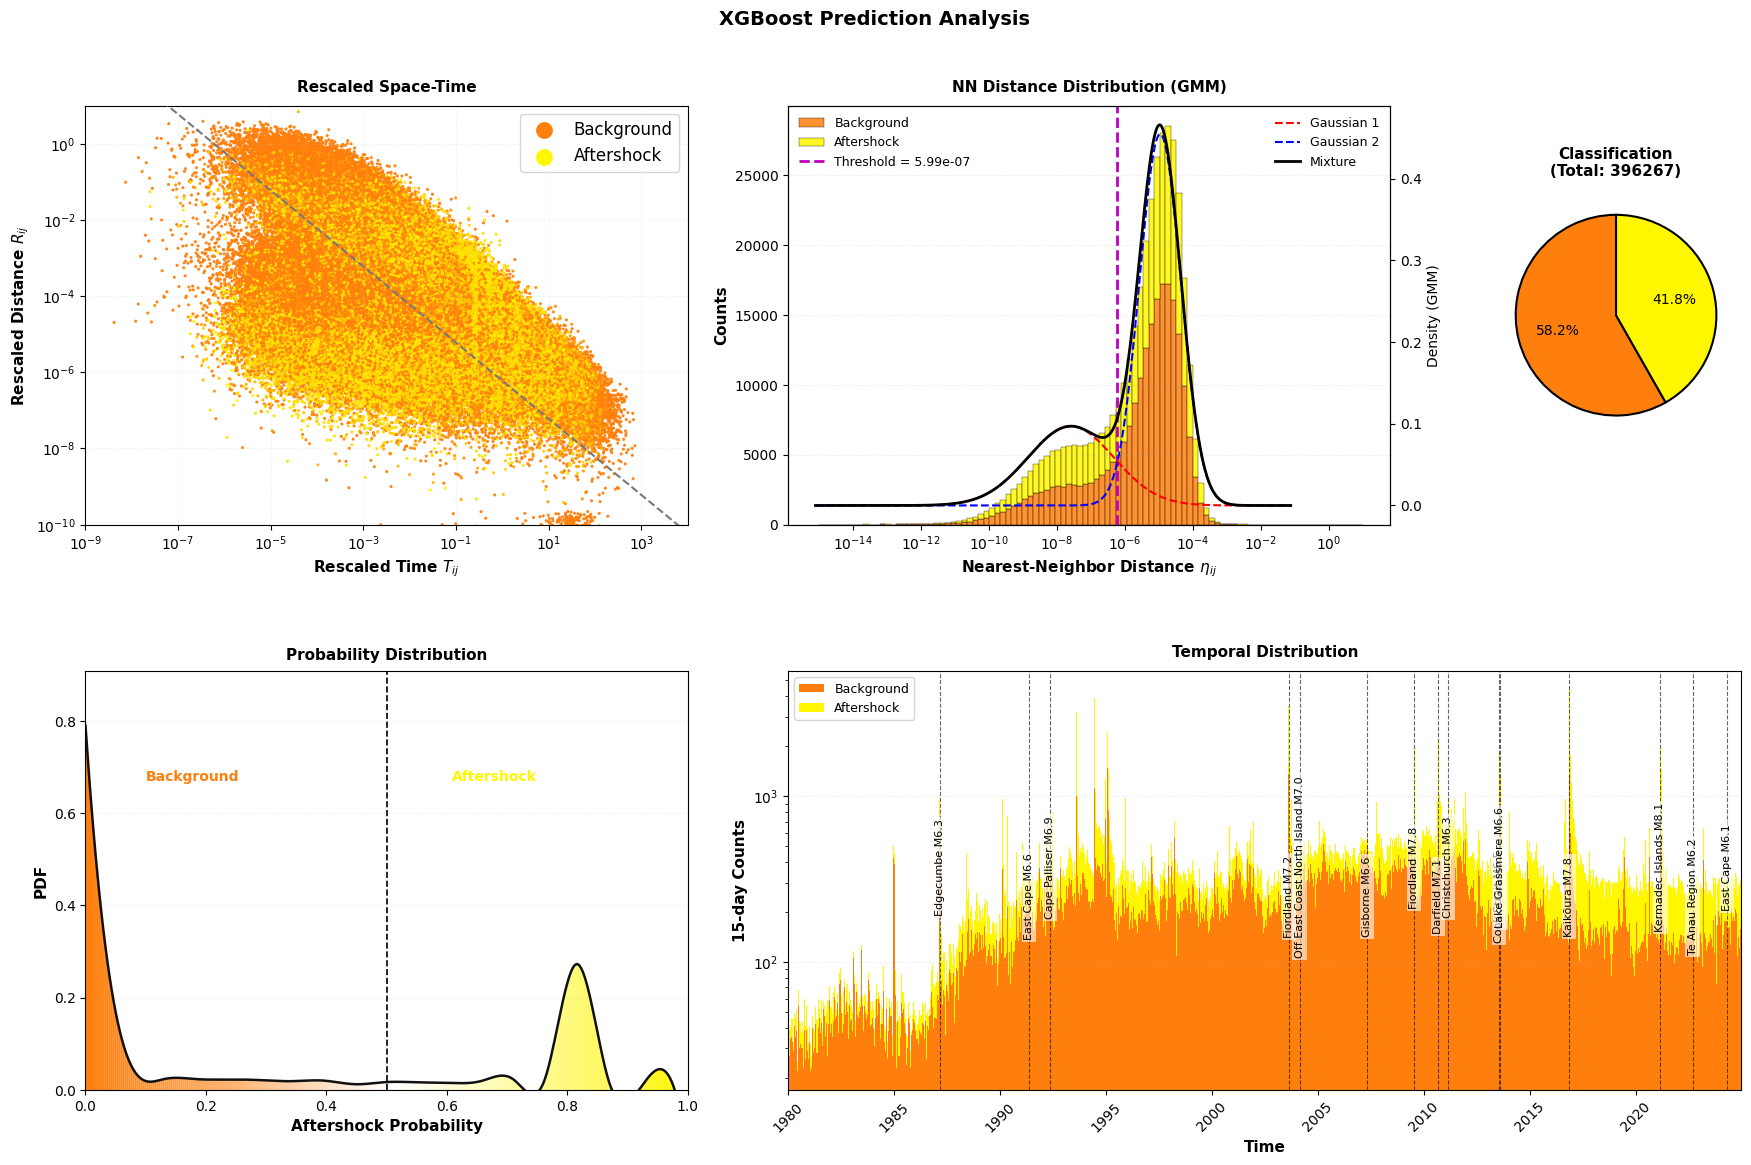

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as md
import matplotlib.colors as mc
from scipy.stats import norm
from sklearn.mixture import GaussianMixture
from matplotlib.font_manager import FontProperties
from scipy.interpolate import make_interp_spline
import warnings
warnings.filterwarnings('ignore')

# =====================================================
# CONFIGURATION
# =====================================================
CONFIG = {
    'figure_size': (18, 12),
    'dpi': 300,
    'colors': {
        'mainshock': '#ff7f0e',   # orange
        'aftershock': '#fff700',  # yellow
        'boundary': '#787878',
        'text': '#606060'
    },
    'scatter_size': 5,
    'prob_bins': 20
}

# =====================================================
# MAJOR HISTORICAL EARTHQUAKES (NZ)
# =====================================================
MAJOR_EVENTS_NZ = {
    '1987-03-02': 'Edgecumbe M6.3',
    '1991-05-13': 'East Cape M6.6',
    '1992-05-19': 'Cape Palliser M6.9',
    '2003-08-22': 'Fiordland M7.2',
    '2004-02-21': 'Off East Coast North Island M7.0',
    '2007-04-30': 'Gisborne M6.6',
    '2009-07-15': 'Fiordland M7.8',
    '2010-09-04': 'Darfield M7.1',
    '2011-02-22': 'Christchurch M6.3',
    '2013-07-21': 'Cook Strait M6.5',
    '2013-08-16': 'Lake Grassmere M6.6',
    '2016-11-14': 'Kaikōura M7.8',
    '2021-03-05': 'Kermadec Islands M8.1',
    '2022-09-10': 'Te Anau Region M6.2',
    '2024-04-30': 'East Cape M6.1'
}

# =====================================================
# LOAD & VALIDATE DATA
# =====================================================
def load_and_validate_data(prediction_csv):
    print(f"📂 Loading: {prediction_csv}")
    df = pd.read_csv(prediction_csv)
    prob_col = next((c for c in df.columns if "Probability" in c and "triggered" in c), None)
    if prob_col is None:
        raise ValueError("❌ No aftershock probability column found.")
    if 'N+' not in df.columns:
        raise ValueError("❌ Column 'N+' not found!")
    return df, prob_col

# =====================================================
# EXTRACT POPULATIONS
# =====================================================
def extract_populations(df, prob_col):
    prob = df[prob_col].values
    pred = np.round(prob)
    main_N = df.loc[pred == 0, 'N+'][df.loc[pred == 0, 'N+'] > 0]
    after_N = df.loc[pred == 1, 'N+'][df.loc[pred == 1, 'N+'] > 0]
    print(f"📊 Background events: {len(main_N)} | Aftershock events: {len(after_N)}")
    return prob, pred, main_N, after_N

# =====================================================
# SCATTER PLOT (T+ vs R+)
# =====================================================
def plot_scatter(ax, df, pred, prob):
    colors = CONFIG['colors']
    if not {'T+', 'R+'}.issubset(df.columns):
        ax.text(0.5, 0.5, 'T+ or R+ not available', ha='center', va='center', transform=ax.transAxes, fontsize=12)
        return

    cmap_continuous = mc.LinearSegmentedColormap.from_list(
        "orange_to_yellow", [colors['mainshock'], colors['aftershock']]
    )

    # Unified gradient: low prob → orange, high prob → yellow
    sc = ax.scatter(df['T+'], df['R+'],
                    s=CONFIG['scatter_size'],
                    c=prob, cmap=cmap_continuous,
                    ec='None', alpha=0.95)

    # Manual legend handles
    ax.scatter([], [], color=colors['mainshock'], label='Background', s=10)
    ax.scatter([], [], color=colors['aftershock'], label='Aftershock', s=10)

    # Log scales
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_xlim(1e-9, 1e4)
    ax.set_ylim(1e-10, 10)
    ax.set_xlabel(r'Rescaled Time $T_{ij}$', fontsize=11, fontweight='bold')
    ax.set_ylabel(r'Rescaled Distance $R_{ij}$', fontsize=11, fontweight='bold')

    ax.legend(frameon=True, loc='upper right', fontsize=12, markerscale=3.5)
    ax.grid(True, alpha=0.3, linestyle=':', linewidth=0.5)
    ax.set_title('Rescaled Space-Time', fontsize=11, fontweight='bold', pad=10)

    # Separation boundary
    threshold = 5.99e-07
    tij = np.array([1e-9, 1e4], dtype=float)
    rij = threshold / tij
    ax.plot(tij, rij, '--', c=colors['boundary'], linewidth=1.5, zorder=10)

# =====================================================
# HISTOGRAM OF N+ WITH GMM
# =====================================================
def plot_histogram(ax, df, pred):
    colors = CONFIG['colors']
    valid = df['N+'] > 0
    log_eta = np.log10(df.loc[valid, 'N+'].values).reshape(-1, 1)

    gmm = GaussianMixture(n_components=2, random_state=0)
    gmm.fit(log_eta)

    means = gmm.means_.flatten()
    stds = np.sqrt(gmm.covariances_).flatten()
    weights = gmm.weights_.flatten()
    order = np.argsort(means)
    mu1, mu2 = means[order]
    sigma1, sigma2 = stds[order]
    w1, w2 = weights[order]

    x = np.linspace(log_eta.min(), log_eta.max(), 2000)
    pdf1 = w1 * norm.pdf(x, mu1, sigma1)
    pdf2 = w2 * norm.pdf(x, mu2, sigma2)
    mixture = pdf1 + pdf2

    threshold_idx = np.argwhere(np.diff(np.sign(pdf1 - pdf2))).flatten()
    threshold = x[threshold_idx][0] if len(threshold_idx) > 0 else None

    ax.hist([df.loc[pred == 0, 'N+'], df.loc[pred == 1, 'N+']],
            bins=10 ** np.linspace(-15, 1, 100),
            stacked=True,
            color=[colors['mainshock'], colors['aftershock']],
            label=['Background', 'Aftershock'],
            edgecolor='black', linewidth=0.3, alpha=0.85)

    x_eta = 10 ** x
    mask = (x_eta >= df['N+'].min()) & (x_eta <= df['N+'].max())
    ax2 = ax.twinx()
    ax2.plot(x_eta[mask], pdf1[mask], 'r--', lw=1.5, label='Gaussian 1')
    ax2.plot(x_eta[mask], pdf2[mask], 'b--', lw=1.5, label='Gaussian 2')
    ax2.plot(x_eta[mask], mixture[mask], 'k-', lw=2, label='Mixture')

    if threshold is not None:
        ax.axvline(10 ** threshold, ls='--', c='m', lw=2,
                   label=f'Threshold = {10 ** threshold:.2e}')

    ax.set_xscale('log')
    ax.set_xlabel(r'Nearest-Neighbor Distance $\eta_{ij}$', fontsize=11, fontweight='bold')
    ax.set_ylabel('Counts', fontsize=11, fontweight='bold')
    ax2.set_ylabel('Density (GMM)')
    ax.legend(frameon=False, fontsize=9, loc='upper left')
    ax2.legend(frameon=False, fontsize=9, loc='upper right')
    ax.grid(True, alpha=0.3, axis='y', linestyle=':')
    ax.set_title('NN Distance Distribution (GMM)', fontsize=11, fontweight='bold', pad=10)
    print(f"📈 GMM Params: μ1={mu1:.2f}, μ2={mu2:.2f}, σ1={sigma1:.2f}, σ2={sigma2:.2f}, threshold={10**threshold:.2e}")

# =====================================================
# PROBABILITY DISTRIBUTION (orange → yellow gradient)
# =====================================================
def plot_probability_distribution(ax, prob):
    color_main = CONFIG['colors']['mainshock']
    color_after = CONFIG['colors']['aftershock']
    boundary_color = '#111111'

    h, bins = np.histogram(prob, bins=np.linspace(0, 1, CONFIG['prob_bins']))
    h = h / h.sum()
    centers = (bins[:-1] + bins[1:]) / 2

    smooth_x = np.linspace(0, 1, 300)
    spline = make_interp_spline(centers, h, k=3)
    smooth_y = spline(smooth_x)

    for i in range(len(smooth_x) - 1):
        x0, x1 = smooth_x[i], smooth_x[i + 1]
        y0, y1 = smooth_y[i], smooth_y[i + 1]
        if x0 < 0.5:
            fade = 1 - (x0 / 0.5) ** 1.2
            color = mc.to_rgba(color_main, alpha=fade)
        else:
            grow = ((x0 - 0.5) / 0.5) ** 1.2
            color = mc.to_rgba(color_after, alpha=grow)
        ax.fill_between([x0, x1], [y0, y1], color=color, linewidth=0)

    ax.plot(smooth_x, smooth_y, color=boundary_color, lw=1.8)
    ax.axvline(0.5, linestyle='--', color='k', lw=1.2)

    ax.set_xlim(0, 1)
    ax.set_ylim(0, smooth_y.max() * 1.15)
    ax.set_xlabel('Aftershock Probability', fontsize=11, fontweight='bold')
    ax.set_ylabel('PDF', fontsize=11, fontweight='bold')
    ax.set_title('Probability Distribution', fontsize=11, fontweight='bold', pad=8)
    ax.grid(True, axis='y', alpha=0.25, linestyle=':')
    ax.text(0.1, smooth_y.max() * 0.85, 'Background', color=color_main, fontsize=10, weight='bold', ha='left')
    ax.text(0.75, smooth_y.max() * 0.85, 'Aftershock', color=color_after, fontsize=10, weight='bold', ha='right')

# =====================================================
# TEMPORAL HISTOGRAM
# =====================================================
def plot_temporal_histogram(ax, df, pred, dt=30):
    """
    Temporal histogram with vivid orange/yellow separation for background vs aftershocks.
    """

    if 'DateTime' not in df.columns:
        ax.text(0.5, 0.5, 'DateTime column missing', ha='center', va='center',
                transform=ax.transAxes, fontsize=12, color='red')
        ax.axis('off')
        return

    df['DateTime'] = pd.to_datetime(df['DateTime'], errors='coerce')
    df = df.dropna(subset=['DateTime'])
    if df.empty:
        ax.text(0.5, 0.5, 'No valid DateTime data', ha='center', va='center',
                transform=ax.transAxes, fontsize=12, color='red')
        ax.axis('off')
        return

    colors = CONFIG['colors']

    # ---- Define bins dynamically from min→max
    start = df['DateTime'].min().floor('D')
    # Round the last bin edge but don't go beyond the last event
    end = df['DateTime'].max().floor('D')
    bins_time = pd.date_range(start, end + pd.Timedelta(days=dt), freq=f'{dt}D')
    

    # ---- Plot stacked histogram with vivid colors
    ax.hist(
        [df.loc[pred == 0, 'DateTime'], df.loc[pred == 1, 'DateTime']],
        bins=bins_time,
        stacked=True,
        color=[colors['mainshock'], colors['aftershock']],
        label=['Background', 'Aftershock'],
        edgecolor='none',   # remove black edges
        linewidth=0,
        alpha=1.0           # full opacity for bright color
    )

    # ---- Axis setup
    if len(df) > 200:
        ax.set_yscale('log')
    ax.set_xlim(start, end)
    ax.set_ylabel(f'{dt}-day Counts', fontsize=11, fontweight='bold')
    ax.set_xlabel('Time', fontsize=11, fontweight='bold')
    ax.xaxis.set_major_formatter(md.DateFormatter('%Y'))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=45)

    # ---- Mark major NZ events
    y_min, y_max = ax.get_ylim()
    y_mid = np.sqrt(y_min * y_max) if y_min > 0 else y_max / 2

    for i, (date_str, label) in enumerate(MAJOR_EVENTS_NZ.items()):
        date = pd.to_datetime(date_str)
        if start <= date <= end:
            ax.axvline(date, color='k', linestyle='--', lw=0.8, alpha=0.6)
            y_pos = y_mid * (1.2 if i % 2 == 0 else 0.8)
            ax.text(date, y_pos, label, rotation=90, fontsize=8,
                    ha='center', va='center',
                    bbox=dict(facecolor='white', alpha=0.6, edgecolor='none', pad=1.5))

    # ---- Legend and styling
    ax.legend(frameon=True, loc='upper left', fontsize=9)
    ax.grid(True, alpha=0.3, axis='y', linestyle=':')
    ax.set_title('Temporal Distribution', fontsize=11, fontweight='bold', pad=10)


# =====================================================
# PIE CHART
# =====================================================
def plot_pie_chart(ax, pred):
    colors = CONFIG['colors']
    n_bg, n_af = (pred == 0).sum(), (pred == 1).sum()
    ax.pie([n_bg, n_af], colors=[colors['mainshock'], colors['aftershock']],
           autopct='%1.1f%%', startangle=90, wedgeprops={"edgecolor": "k", 'linewidth': 1.5})
    ax.set_title(f'Classification\n(Total: {n_bg + n_af})', fontsize=11, fontweight='bold', pad=10)

# =====================================================
# MAIN PLOTTING FUNCTION
# =====================================================
def plot_from_prediction_csv(prediction_csv, figure_name='NZ_XGB_FinalPlot.png', dt=15, save=True):
    df, prob_col = load_and_validate_data(prediction_csv)
    prob, pred, main_N, after_N = extract_populations(df, prob_col)

    fig = plt.figure(figsize=CONFIG['figure_size'], dpi=100)
    gs = fig.add_gridspec(2, 5, hspace=0.35, wspace=0.4, left=0.06, right=0.98, top=0.90, bottom=0.08)

    ax1 = fig.add_subplot(gs[0, 0:2])
    ax2 = fig.add_subplot(gs[0, 2:4])
    ax_pie = fig.add_subplot(gs[0, 4])
    ax3 = fig.add_subplot(gs[1, 0:2])
    ax4 = fig.add_subplot(gs[1, 2:])

    plot_scatter(ax1, df, pred, prob)
    plot_histogram(ax2, df, pred)
    plot_pie_chart(ax_pie, pred)
    plot_probability_distribution(ax3, prob)
    plot_temporal_histogram(ax4, df, pred, dt)

    # # Unified colorbar for probability
    # sm = plt.cm.ScalarMappable(cmap=mc.LinearSegmentedColormap.from_list(
    #     "orange_to_yellow", [CONFIG['colors']['mainshock'], CONFIG['colors']['aftershock']]))
    # sm.set_array([])
    # cbar = fig.colorbar(sm, ax=[ax1, ax2, ax3, ax4], orientation='horizontal', fraction=0.035, pad=0.08)
    # cbar.set_label('Aftershock Probability', fontsize=10, fontweight='bold')

    fig.suptitle('XGBoost Prediction Analysis ', fontsize=14, fontweight='bold')
    if save:
        #plt.savefig(figure_name, dpi=CONFIG['dpi'], bbox_inches='tight')
        plt.savefig(
         "XGB_Aftershock_Analysis.png",
         dpi=600,                     # super-high resolution (300–600 for publication)
         bbox_inches='tight',         # trims extra white borders
         pad_inches=0.1,              # small padding so labels aren't cut off
         transparent=True,            # keeps background clean (for slides/journals)
         facecolor='white'            # ensures white background if transparent=False
        )
     
        print(f"✅ Plot saved as {figure_name}")
    plt.show()

# =====================================================
# RUN EXAMPLE
# =====================================================
if __name__ == "__main__":
    csv_path = "/home/ashraf/Desktop/THESIS-FINAL/ML-pipeline/XGB/xgb_real_data_predictions_gb.csv"
    plot_from_prediction_csv(csv_path, save=True)
